# Denton loss coefficient

In [1]:
def which(check,solver,method,case,geom,fluid,mesh):
    dirs_data = '/home/matar/Codes/MUSICAA/RANS/LS89/'+\
               geom+'_'+mesh+'/' 
    
    if method=='LES':
        dirs_data = '/home/matar/Codes/MUSICAA/PFG/LS89/'+\
               geom+'_'+mesh+'/'
        if fluid=='r134a':
            dirs_data = '/home/matar/Codes/MUSICAA/PRS/LS89/'+\
                   geom+'_'+mesh+'/'
        
    if method=='RANS':
        dirs_data = '/home/matar/Codes/MUSICAA/RANS/LS89/'+\
               geom+'_'+mesh+'/'
        
    if method=='DES':
        dirs_data = '/home/matar/Codes/MUSICAA/DES/LS89/'+\
               geom+'_'+mesh+'/'

    if check:
        return dirs_data
    else:
        if fluid=='r134a':
            fluid = 'PRS'
        else:
            fluid = 'PFG'
        dirs_data+= f'Postproc_{fluid.lower()}/{case}/'

    return dirs_data


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import readvars_turb as rv
import plotvars_turb as pv

# Compare computations
#=====================
# checks  = [False,False,False,False]
# solvers = ['musicaa','musicaa','musicaa','musicaa']
# methods = ['RANS','LES','RANS','LES']
# is_curv = True
# cases   = ['dtglobal_CFL10_IRS2_filter_RANS','irene_7','dtglobal_CFL10_IRS2_filter_RANS','irene_6']
# endians = ['small','big','small','big']
# geoms   = ['shroud','shroud','shroud','shroud']
# fluids  = ['air','air','r134a','r134a']
# meshes  = ['F_air','C_air_musica3D','F_r134a','C_r134a_musica3D']
# nx_procs= [50,50,50,50]
# nproc_zs= [1,5,1,5]
# wall_jmin = [True,True,True,True]
# styles  = ['-.r','-or','-.b','-^b']

# # R134a
# # -----
# checks  = [False,False,False,False]
# solvers = ['musicaa','musicaa','musicaa','musicaa']
# methods = ['LES','LES','LES']
# is_curv = True
# cases   = ['irene_Tu0_5','irene_Tu10_Rpert_5','irene_Tu20_Rpert_7']
# endians = ['big','big','big']
# geoms   = ['Mach17','Mach17','Mach17']
# fluids  = ['r134a','r134a','r134a']
# meshes  = ['C_refined','C_refined','C_refined']
# L_refs = [0.010,0.010,0.010]
# pitchs = [1.4633321,1.4633321,1.4633321]
# wall_jmin = [True,True,True]
# styles  = ['-b','-^r','-.k']
# ind_LE = [145,145,145] # RANS & LES
# ind_TE = [1850,1850,1850] # RANS & LES

# checks  = [False,False,False,False]
# solvers = ['musicaa','musicaa']
# methods = ['LES','LES']
# is_curv = True
# cases   = ['irene_7','irene_6']
# endians = ['big','big']
# geoms   = ['shroud','shroud']
# fluids  = ['air','air']
# meshes  = ['C_air_musica3D','M_air_musica3D']
# nx_procs= [50,50,50,50]
# nproc_zs= [5,7]
# wall_jmin = [True,True]
# styles  = ['-*g','-k']


# NICFD5
# -----
checks  = [False,False,False,False]
solvers = ['musicaa','musicaa','musicaa','musicaa']
methods = ['RANS','LES','LES']
is_curv = True
cases   = ['optim_baseline','irene_Tu0_6']
endians = ['small','big','big']
geoms   = ['Mach17','Mach17','Mach17']
fluids  = ['r134a','r134a','r134a']
meshes  = ['C_r134a','C_refined','C_refined']
L_refs = [0.010,0.010,0.010]
pitchs = [1.4633321,1.4633321,1.4633321]
wall_jmin = [True,True,True]
styles  = ['-b','-^r','-.k']
ind_LE = [12,145,145] # RANS & LES
ind_TE = [285,1850,1850] # RANS & LES

dirs_data = [which(checks[i],solvers[i],methods[i],case,geoms[i],fluids[i],meshes[i]) \
             for i,case in enumerate(cases)]


# Get data

In [3]:
## %matplotlib widget
# %matplotlib auto
var = 'M'

import prsv_model_arr as PR

comp_data = {}
for ii,dir_data in enumerate(dirs_data):
    
    # General information
    var_list = ['rho','u','v','w','p','T','rhou','rhov','rhow','rhoe', \
                'rho**2','uu','vv','ww','uv','uw','vw','vT','p**2','T**2',\
                'mu','divloc','divloc2']
    stats1,stats2 = 1,2
    stats = stats1
    if (var not in var_list):
        stats = stats2
    dict_info = rv.read_info(dir_data)
    n_bl   = dict_info['nbloc']
    nz     = dict_info['nz_bl1']
    # LS89 Mach17
    L_ref = 0.010
    pitch = 1.4633321
    # # Baumgartner
    # L_ref = 0.01563475852
    # pitch = 1.004682375
    # isentropic Mach computation
    if fluids[ii]=='air':
        # air
        p0_in = 785000
        T0_in = 293
        p_in = 7.78e5
        u_in   = 38.3
        rho_in = 9.15
        gam_in = 1.4
    else:
        # r134a
        p0_in = 483000
        T0_in = 293
        u_in = 13.6233
        p_in = 4.79e6
        T_in = 292.8
        rho_in = 22.46
        gam_in = PR.cpcalc_tro(T_in,rho_in)/PR.cvcalc_tro(T_in,rho_in)
    norm   = u_in
        
    if methods[ii]=='RANS':
        is_RANS=True
    else:
        is_RANS=False
            
    # Wall length
    if wall_jmin[ii]:
        nw = sum([dict_info['nx_bl3'],dict_info['nx_bl4'], \
                  dict_info['nx_bl6'],dict_info['nx_bl7']])
    else:
        nw = sum([dict_info['ny_bl3'],dict_info['nx_bl4'], \
                  dict_info['ny_bl6'],dict_info['ny_bl7']])
    nw_loc = 0

    data,data2 = {},{}
    vmin,vmax = [],[]
    p0        = []
    xw,yw     = np.zeros((nw)),np.zeros((nw))
    xm1,xp1   = np.zeros((nw)),np.zeros((nw))
    dxw       = np.zeros((nw))
    pw,cpw    = np.zeros((nw)),np.zeros((nw))
    theta,r   = np.zeros((nw)),np.zeros((nw))
    muw,la    = np.zeros((nw)),np.zeros((nw))
    rhow,y1   = np.zeros((nw))+1,np.zeros((nw))
    x1_,y1_   = np.zeros((nw)),np.zeros((nw))
    x2_,y2_   = np.zeros((nw)),np.zeros((nw))
    s         = np.zeros((nw))
    Twa,tauw  = np.zeros((nw)),np.zeros((nw))
    prms      = np.zeros((nw))
    duxw,duyw,duzw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    dvxw,dvyw,dvzw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    dwxw,dwyw,dwzw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    tau = np.zeros((nw,2,2))

    # For regular grid interpolation/streamlines
    u_flat   = []
    v_flat   = []
    x_flat   = []
    y_flat   = []
    var_flat = []
    rho_flat = []
    p_flat = []
    T_flat = []
    k_flat   = []
    P_flat   = []
    P_c_flat = []
    P_s_flat = []
    M_is_flat = []
    M_flat = []
    p_wake_flat = []
    rhou_flat   = []
    rhov_flat   = []
    s_flat   = []

    # Block caracteristics
    # /!\ wall direction is clockwise
    blcar = {}
    for bl in range(n_bl):
        bl+=1
        blcar[f'block_{bl}'] = {}
        if bl==3 or bl==4 or bl==6 or bl==7:
            blcar[f'block_{bl}']['wall'] = True
        else:
            blcar[f'block_{bl}']['wall'] = False

        if (bl==3 or bl==6 or bl==7) and not wall_jmin[ii]:
            # Wall location
            blcar[f'block_{bl}']['imax'] = True
            blcar[f'block_{bl}']['jmin'] = False
        else:
            # Wall location
            blcar[f'block_{bl}']['jmin'] = True
            blcar[f'block_{bl}']['imax'] = False

    # Extract data
    for bl in range(n_bl):
        bl+=1

        # Retrieve data from readvars
        nx,ny,nz,x,y,z = rv.read_grid(dir_data+'grid_bl{}.bin'.format(bl),is_curv,endians[ii])
        bl_data,data   = rv.extr_dict(is_RANS,stats1,bl,nx,ny,dir_data,meshes[ii],data)
        bl_data2,data2 = rv.extr_dict(is_RANS,stats2,bl,nx,ny,dir_data,meshes[ii],data2)

        # isentropic Mach number
        data[f'block_{bl}']['M_is'] = np.sqrt(2/(gam_in-1)*\
              ((p0_in/bl_data['p'])**((gam_in-1)/gam_in)-1))
        M_is_flat.append(data[f'block_{bl}']['M_is'].flatten())

        # Pressure in wake
        data[f'block_{bl}']['p_wake'] = bl_data['p']/p0_in
        p_wake_flat.append(data[f'block_{bl}']['p_wake'].flatten())

        if stats==1:
            data[f'block_{bl}'][var] = bl_data[var]
        else:
            data[f'block_{bl}'][var] = bl_data2[var]
            
        # More stuff
        data[f'block_{bl}']['M'] = bl_data2['M']
        M_flat.append(data[f'block_{bl}']['M'].flatten())
        
        # Thermos
        data[f'block_{bl}']['u'] = bl_data['u']
        data[f'block_{bl}']['v'] = bl_data['v']
        data[f'block_{bl}']['rhou'] = bl_data['rhou']
        data[f'block_{bl}']['rhov'] = bl_data['rhov']
        data[f'block_{bl}']['p'] = bl_data['p']
        data[f'block_{bl}']['T'] = bl_data['T']
        data[f'block_{bl}']['rho'] = bl_data['rho']
        data[f'block_{bl}']['s'] = bl_data2['s']
        data[f'block_{bl}']['mu'] = bl_data['mu']

        # Derivatives
        data[f'block_{bl}']['omz'] = -bl_data2['b3']
        data[f'block_{bl}']['dux'] = bl_data2['rho*dux']/bl_data['rho']
        data[f'block_{bl}']['duy'] = bl_data2['rho*duy']/bl_data['rho']
        data[f'block_{bl}']['dvx'] = bl_data2['rho*dvx']/bl_data['rho']
        data[f'block_{bl}']['dvy'] = bl_data2['rho*dvy']/bl_data['rho']
        
        # Reynolds stress
        data[f'block_{bl}']['uv'] = bl_data['uv']-bl_data['u']*bl_data['v']
        
        # Flattened coords
        data[f'block_{bl}']['x'],data[f'block_{bl}']['y'] = x/L_ref,y/L_ref

        # Extract wall data
        if blcar[f'block_{bl}']['wall']:
            if blcar[f'block_{bl}']['imax']:
                # Wall coordinates
                xw[nw_loc:nw_loc+ny] = x[-1,:]/L_ref
                yw[nw_loc:nw_loc+ny] = y[-1,:]/L_ref
                # Compute first cell height
                x1_[nw_loc:nw_loc+ny] = x[-2,:]/L_ref
                y1_[nw_loc:nw_loc+ny] = y[-2,:]/L_ref
                if bl==6:
                    yw[nw_loc:nw_loc+ny] +=-pitch
                    y1_[nw_loc:nw_loc+ny]+=-pitch
                y1[nw_loc:nw_loc+ny]  = (np.sqrt((x1_-xw)**2+(y1_-yw)**2))[nw_loc:nw_loc+ny]
                # Cp
                pw[nw_loc:nw_loc+ny] = bl_data['p'][-1,:]
                p0.append(pw.max())
                # Tw
                Twa[nw_loc:nw_loc+ny] = bl_data['T'][-1,:]
                # Cf
                muw[nw_loc:nw_loc+ny]  = bl_data['mu'][-1,:]
                rhow[nw_loc:nw_loc+ny] = bl_data['rho'][-1,:]
                duxw[nw_loc:nw_loc+ny] = bl_data2['rho*dux'][-1,:]
                duyw[nw_loc:nw_loc+ny] = bl_data2['rho*duy'][-1,:]
                duzw[nw_loc:nw_loc+ny] = bl_data2['rho*duz'][-1,:]
                dvxw[nw_loc:nw_loc+ny] = bl_data2['rho*dvx'][-1,:]
                dvyw[nw_loc:nw_loc+ny] = bl_data2['rho*dvy'][-1,:]
                dvzw[nw_loc:nw_loc+ny] = bl_data2['rho*dvz'][-1,:]
                dwxw[nw_loc:nw_loc+ny] = bl_data2['rho*dwx'][-1,:]
                dwyw[nw_loc:nw_loc+ny] = bl_data2['rho*dwy'][-1,:]
                dwzw[nw_loc:nw_loc+ny] = bl_data2['rho*dwz'][-1,:]
                # In cartesian coordinates
                tau[nw_loc:nw_loc+ny,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+ny]
                tau[nw_loc:nw_loc+ny,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+ny]
                tau[nw_loc:nw_loc+ny,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+ny]
                tau[nw_loc:nw_loc+ny,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+ny]

                # P_rms wall
                prms[nw_loc:nw_loc+ny] = np.sqrt((bl_data['p**2']-bl_data['p']**2))[-1,:]

                nw_loc+=ny

            if blcar[f'block_{bl}']['jmin']:
                # Wall coordinates
                xw[nw_loc:nw_loc+nx]    = x[:,0]/L_ref
                yw[nw_loc:nw_loc+nx]    = y[:,0]/L_ref
                # Compute first cell height
                x1_[nw_loc:nw_loc+nx]   = x[:,1]/L_ref
                y1_[nw_loc:nw_loc+nx]   = y[:,1]/L_ref
                if bl==6:
                    yw[nw_loc:nw_loc+nx] +=-pitch
                    y1_[nw_loc:nw_loc+nx]+=-pitch
                y1[nw_loc:nw_loc+nx]    = (np.sqrt((x1_-xw)**2+(y1_-yw)**2))[nw_loc:nw_loc+nx]
                # Cp
                pw[nw_loc:nw_loc+nx] = bl_data['p'][:,0]
                p0.append(pw.max())
                # Tw
                Twa[nw_loc:nw_loc+nx] = bl_data['T'][:,0]
                # Cf
                muw[nw_loc:nw_loc+nx]  = bl_data['mu'][:,0]
                rhow[nw_loc:nw_loc+nx] = bl_data['rho'][:,0]
                duxw[nw_loc:nw_loc+nx] = bl_data2['rho*dux'][:,0]
                duyw[nw_loc:nw_loc+nx] = bl_data2['rho*duy'][:,0]
                duzw[nw_loc:nw_loc+nx] = bl_data2['rho*duz'][:,0]
                dvxw[nw_loc:nw_loc+nx] = bl_data2['rho*dvx'][:,0]
                dvyw[nw_loc:nw_loc+nx] = bl_data2['rho*dvy'][:,0]
                dvzw[nw_loc:nw_loc+nx] = bl_data2['rho*dvz'][:,0]
                dwxw[nw_loc:nw_loc+nx] = bl_data2['rho*dwx'][:,0]
                dwyw[nw_loc:nw_loc+nx] = bl_data2['rho*dwy'][:,0]
                dwzw[nw_loc:nw_loc+nx] = bl_data2['rho*dwz'][:,0]
                # In cartesian coordinates
                tau[nw_loc:nw_loc+nx,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+nx]

                # P_rms wall
                prms[nw_loc:nw_loc+nx] = np.sqrt((bl_data['p**2']-bl_data['p']**2))[:,0]

                nw_loc+=nx
                
        if bl==6:
            data[f'block_{bl}']['y']+=-pitch

        # Flat coords
        data[f'block_{bl}']['x_flat'] = data[f'block_{bl}']['x'].flatten()
        data[f'block_{bl}']['y_flat'] = data[f'block_{bl}']['y'].flatten()
        x_flat.append(data[f'block_{bl}']['x'].flatten())
        y_flat.append(data[f'block_{bl}']['y'].flatten())
                
        # Operations for grid interpolation and streamlines
        u_flat.append(bl_data['u'].flatten())
        v_flat.append(bl_data['v'].flatten())
        rho_flat.append(bl_data['rho'].flatten())
        p_flat.append(bl_data['p'].flatten())
        T_flat.append(bl_data['T'].flatten())
        rhou_flat.append(bl_data['rhou'].flatten())
        rhov_flat.append(bl_data['rhov'].flatten())
        s_flat.append(bl_data2['s'].flatten())
        var_flat.append(data[f'block_{bl}'][var].flatten())
        # Per block
        data[f'block_{bl}']['u_flat'] = bl_data['u'].flatten()
        data[f'block_{bl}']['v_flat'] = bl_data['v'].flatten()
        data[f'block_{bl}']['rhou_flat'] = bl_data['rhou'].flatten()
        data[f'block_{bl}']['rhov_flat'] = bl_data['rhov'].flatten()
        data[f'block_{bl}']['T_flat'] = bl_data['T'].flatten()
        data[f'block_{bl}']['rho_flat'] = bl_data['rho'].flatten()
        data[f'block_{bl}']['dux_flat'] = data[f'block_{bl}']['dux'].flatten()
        data[f'block_{bl}']['duy_flat'] = data[f'block_{bl}']['duy'].flatten()
        data[f'block_{bl}']['dvx_flat'] = data[f'block_{bl}']['dvx'].flatten()
        data[f'block_{bl}']['dvy_flat'] = data[f'block_{bl}']['dvy'].flatten()
        data[f'block_{bl}']['uv_flat'] = data[f'block_{bl}']['uv'].flatten()
        data[f'block_{bl}']['mu_flat'] = bl_data['mu'].flatten()
        data[f'block_{bl}']['s_flat'] = bl_data2['s'].flatten()
        data[f'block_{bl}']['omz_flat'] = -bl_data2['b3'].flatten()
        data[f'block_{bl}']['p_flat'] = bl_data['p'].flatten()
        data[f'block_{bl}']['var_flat'] = data[f'block_{bl}'][var].flatten()

        # Operations for Mach number and speed of sound
        data[f'block_{bl}']['mu'] = bl_data['mu']
        data[f'block_{bl}']['vort']  =-bl_data2['b3']*L_ref/u_in

        vmin_ = data[f'block_{bl}'][var].min()
        vmax_ = data[f'block_{bl}'][var].max()
        vmin.append(vmin_)
        vmax.append(vmax_)

    # Add more useful stuff
    #######################
    
    # Inlet data
    data['n_bl'] = n_bl
    data['u_in'] = u_in
    data['rho_in'] = rho_in
    data['vmin'] = min(vmin)
    data['vmax'] = max(vmax)
    data['L_ref'] = L_ref
    data['norm'] = norm

#     # Outlet pitchwise average
#     i = 45
#     rho_out = 0.5*(np.mean(data['block_8']['rho'][i,:])+np.mean(data['block_9']['rho'][i,:]))
#     u_out = 0.5*(np.mean(data['block_8']['u'][i,:])+np.mean(data['block_9']['u'][i,:]))
#     v_out = 0.5*(np.mean(data['block_8']['v'][i,:])+np.mean(data['block_9']['v'][i,:]))
#     U_out = np.sqrt(u_out**2+v_out**2)
#     mu_out = 0.5*(np.mean(data['block_8']['mu'][i,:])+np.mean(data['block_9']['mu'][i,:]))
#     M_out = 0.5*(np.mean(data['block_8']['M'][i,:])+np.mean(data['block_9']['M'][i,:]))
#     thet_out = np.arctan(v_out/u_out)*180/np.pi
#     Re_out = rho_out*U_out*L_ref/mu_out
#     print('Re_out =',Re_out)
#     print('M_out =',M_out)
#     print('thet_out =',thet_out)

    # REARRANGING FUNCTIONS
    if wall_jmin[ii]:
        def rearrange(x,dict_info):
            i32 = dict_info['nx_bl3']
            i41 = i32
            i42 = dict_info['nx_bl3']+dict_info['nx_bl4']
            i61 = i42
            i62 = i61+dict_info['nx_bl6']
            i71 = i62
            i72 = i71+dict_info['nx_bl7']
            x3 = x[:i32]
            x4 = x[i41:i42]
            x6 = x[i61:i62]
            x7 = x[i71:i72]

            return np.hstack((x3,x4,x7,x6))

    else:
        def rearrange(x,d):
            len_ = d['ny_bl3']+d['nx_bl4']
            # save bl6 coords
            x_ = np.zeros(d['ny_bl6'])
            x_ = x[len_:len_+d['ny_bl6']].copy()
            # rotate array
            x[len_:len_+d['ny_bl7']] = x[-d['ny_bl7']:].copy()
            x[-d['ny_bl6']:] = x_.copy()

            return x
    
    xw = rearrange(xw,dict_info)
    yw = rearrange(yw,dict_info)
    pw = rearrange(pw,dict_info)
    data['xw'] = xw.copy()
    data['yw'] = yw.copy()
    # data['pw'] = pw.copy()

    # Translate everything so stagnation point is @ (0,0)
    ind_p0 = np.argmax(pw) # index of P0 to start wall coords
    xw_p0 = xw[ind_p0]
    yw_p0 = yw[ind_p0]
    thet = 49*np.pi/180
    coords = np.vstack((xw,yw))
    R = np.array([[np.cos(thet),-np.sin(thet)],[np.sin(thet),np.cos(thet)]])
    coords = np.matmul(R,coords)
    xw = coords[0,:]
    yw = coords[1,:]
    xw = xw-xw.min()
    xw = xw/(xw.max()-xw.min())
    yw = yw/(xw.max()-xw.min())
    # Store
    data['xw_r'] = xw
    data['yw_r'] = yw
    # data['xw'] = xw.copy()
    # data['yw'] = yw.copy()
    
    # Isentropic Mach number
    data['p0'] = p0_in
    data['p/p0'] = pw/data['p0']
    if fluids[ii]=='air':
        gam = 1.4
    else:
        gam = PR.cpcalc_tro(T_in,rho_in)/PR.cvcalc_tro(T_in,rho_in)
        print('gam_nov =',gam)
    gam1= gam-1
    data['M_is'] = np.sqrt(((data['p/p0'])**(-gam1/gam)-1)*2/gam1)
    
    # Wall normals
    nwall   = np.zeros((nw,2))
    twall   = np.zeros((nw,2))
#     if methods[ii]=='LES' or methods[ii]=='DES':
#         nx_proc = nx_procs[ii]
#         nproc_z = nproc_zs[ii]
#         ijacob  = np.zeros((nw))
#         nwalldl = np.zeros((nw))
#         with open(dirs_data[ii]+'norm_surf.dat','r') as f:
#             dat = np.loadtxt(f)
#             j=0
#             k=0
#             for i in range(dat.shape[0]):

#                 if i%nx_proc==0 and i!=0:
#                     k+=(nproc_z-1)*nx_proc
#                 i+=k
#                 if i>=dat.shape[0]:
#                     break

#                 nwalldl[j] = np.sqrt(dat[i,0]**2+dat[i,1]**2)
#                 nwall[j,0] = dat[i,2]
#                 nwall[j,1] = dat[i,3]
#                 ijacob[j]  = dat[i,4]

#                 j+=1
                    
#     else:
#         with open(dir_data+'norm_surf.dat','r') as f:
#             dat = np.loadtxt(f)
#             nxwalldl = dat[:,0]
#             nywalldl = dat[:,1]
#             nxwall = dat[:,2]
#             nywall = dat[:,3]
#             # dl     = dat[:,4]
#             ijacob = dat[:,4]
#             nwall[:,0],nwall[:,1] = nxwall,nywall
#             nwalldl = np.sqrt(nxwalldl**2+nywalldl**2)
#             data['nwall'] = nwall
        
#     if methods[ii]=='LES' or methods[ii]=='DES':
#         # Apply moving average to filter out jacobi oscillations
#         N = 20
#         start = N+200
#         finish = -N-200
#         nwall[start:finish,0] = np.convolve(nwall[:,0],np.ones(N)/N,mode='same')[start:finish]
#         nwall[start:finish,1] = np.convolve(nwall[:,1],np.ones(N)/N,mode='same')[start:finish]
#         nwalldl[start:finish] = np.convolve(nwalldl,np.ones(N)/N,mode='same')[start:finish]
#         ijacob[start:finish] = np.convolve(ijacob,np.ones(N)/N,mode='same')[start:finish]
        
    # Wall normals
    nwall = np.zeros((nw,2))
    twall = np.zeros((nw,2))
    with open(dir_data+'norm_surf.dat','r') as f:
        dat = np.loadtxt(f)
        nxwalldl = dat[:,0]
        nywalldl = dat[:,1]
        nxwall = dat[:,2]
        nywall = dat[:,3]
        # dl     = dat[:,4]
        ijacob = dat[:,4]
        nwall[:,0],nwall[:,1] = nxwall,nywall
        nwalldl = np.sqrt(nxwalldl**2+nywalldl**2)
        data['nwall'] = nwall
         
    # Wall friction
    twall[:,0] = nwall[:,1]
    twall[:,1] = -nwall[:,0]
    tauw = ((tau[...,0,0]*nwall[:,0]+tau[...,0,1]*nwall[:,1])*twall[:,0] + \
            (tau[...,1,0]*nwall[:,0]+tau[...,1,1]*nwall[:,1])*twall[:,1]).copy()
        
    # Rearrange
    nwall[:,0] = rearrange(nwall[:,0],dict_info)
    nwall[:,1] = rearrange(nwall[:,1],dict_info)
    twall[:,0] = rearrange(twall[:,0],dict_info)
    twall[:,1] = rearrange(twall[:,1],dict_info)
    ijacob = rearrange(ijacob,dict_info)
    nwalldl = rearrange(nwalldl,dict_info)
    tauw = rearrange(tauw,dict_info)
    y1 = rearrange(y1,dict_info)
    x1 = rearrange(nwalldl,dict_info)/L_ref
    rhow = rearrange(rhow,dict_info)
    muw = rearrange(muw,dict_info)
    utau = np.sqrt(abs(tauw)/rhow)
    
    # Save
    data['cf'] = tauw/(0.5*rho_in*u_in**2)
    data['nwall'] = nwall
    data['twall'] = twall

    # Non dimensional wall data
    normw = utau
    data['yp'] = y1*L_ref*utau/muw*rhow
    data['xp'] = x1*L_ref*utau/muw*rhow
    data['s']  = x1
    data['nw'] = nw
    data['tauw'] = tauw
    data['utau'] = utau
    data['rhow'] = rhow
    data['muw']  = muw
    data['pw']   = pw

    # Flattened data
    data['x_flat'] = np.hstack(x_flat)
    data['y_flat'] = np.hstack(y_flat)
    data['M_is_flat'] = np.hstack(M_is_flat)
    np.nan_to_num(data['M_is_flat'],0)
    data['M_flat'] = np.hstack(M_flat)
    data['p_wake_flat'] = np.hstack(p_wake_flat)
    data['u_flat'] = np.hstack(u_flat)
    data['v_flat'] = np.hstack(v_flat)
    data['rho_flat'] = np.hstack(rho_flat)
    data['p_flat'] = np.hstack(p_flat)
    data['T_flat'] = np.hstack(T_flat)
    data['var_flat'] = np.hstack(var_flat)
    
    # Store
    comp_data[f'{ii}'] = data.copy()
    
print('done')

Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...


/tmp/ipykernel_332230/59754897.py:131: RuntimeWarning: invalid value encountered in sqrt
  data[f'block_{bl}']['M_is'] = np.sqrt(2/(gam_in-1)*\


Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
gam_nov = 1.1027388843163126
Reading grid...
Reading stats...
Reading stats...


/tmp/ipykernel_332230/59754897.py:388: RuntimeWarning: invalid value encountered in sqrt
  data['M_is'] = np.sqrt(((data['p/p0'])**(-gam1/gam)-1)*2/gam1)


Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
gam_nov = 1.1027388843163126
done


## Hydro boundary layer interpolation

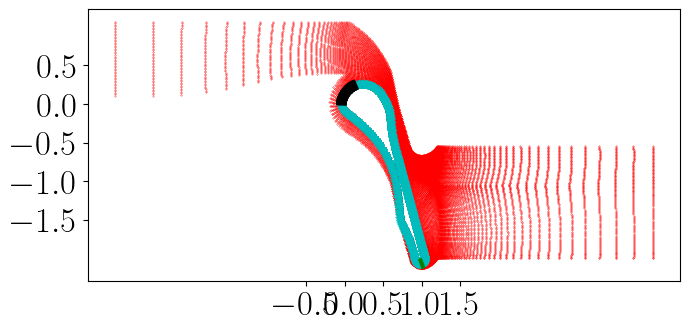

done


In [4]:
# %matplotlib widget
# %matplotlib auto

var_list = ['rhou','rhov','p','rho','omz','x','y']

# Suction side
# ============
for var in var_list:
    for ii,dir_data in enumerate(dirs_data):
        comp_data[f'{ii}'][f'{var}_flat'] = np.hstack((comp_data[f'{ii}']['block_2'][f'{var}_flat'],\
                                                       comp_data[f'{ii}']['block_3'][f'{var}_flat'],\
                                                       comp_data[f'{ii}']['block_4'][f'{var}_flat'],\
                                                       comp_data[f'{ii}']['block_5'][f'{var}_flat'],\
                                                       comp_data[f'{ii}']['block_6'][f'{var}_flat'],\
                                                       comp_data[f'{ii}']['block_7'][f'{var}_flat'],\
                                                       comp_data[f'{ii}']['block_8'][f'{var}_flat'],\
                                                       comp_data[f'{ii}']['block_9'][f'{var}_flat']))

# # Pressure side
# # =============
# for var in var_list:
#     for ii,dir_data in enumerate(dirs_data):
#         if var=='y':
#             comp_data[f'{ii}'][f'{var}_flat'] = np.hstack((comp_data[f'{ii}']['block_1'][f'{var}_flat'],\
#                                                            comp_data[f'{ii}']['block_2'][f'{var}_flat']-pitch,\
#                                                            comp_data[f'{ii}']['block_3'][f'{var}_flat'],\
#                                                            comp_data[f'{ii}']['block_5'][f'{var}_flat']-pitch,\
#                                                            comp_data[f'{ii}']['block_6'][f'{var}_flat']))
#         else:
#             comp_data[f'{ii}'][f'{var}_flat'] = np.hstack((comp_data[f'{ii}']['block_1'][f'{var}_flat'],\
#                                                            comp_data[f'{ii}']['block_2'][f'{var}_flat'],\
#                                                            comp_data[f'{ii}']['block_3'][f'{var}_flat'],\
#                                                            comp_data[f'{ii}']['block_5'][f'{var}_flat'],\
#                                                            comp_data[f'{ii}']['block_6'][f'{var}_flat']))
        
# Create new grid based on LES coarse mesh normals
# ================================================
ii=0
# ================================================
nxwall = comp_data[f'{ii}']['nwall'][:,0]
nywall = comp_data[f'{ii}']['nwall'][:,1]
txwall = comp_data[f'{ii}']['twall'][:,0]
tywall = comp_data[f'{ii}']['twall'][:,1]
nw = comp_data[f'{ii}']['nw']
xw = comp_data[f'{ii}']['xw']
yw = comp_data[f'{ii}']['yw']
s = np.hstack((np.array([0]),np.sqrt((xw[1:]-xw[:-1])**2+(yw[1:]-yw[:-1])**2)[75:],\
               np.sqrt((xw[1:]-xw[:-1])**2+(yw[1:]-yw[:-1])**2)[:75]))
s = np.cumsum(s)

# Compute local angle
theta = np.arctan(abs(nywall/nxwall))
for i,thet in enumerate(theta):
    if nywall[i]<=0:
        theta[i] = 2*np.pi-theta[i]
    if nxwall[i]>=0 and nywall[i]>=0:
        theta[i] = np.pi-theta[i]
    if nxwall[i]>=0 and nywall[i]<=0:
        theta[i] = 3*np.pi-theta[i]
theta = np.pi-theta

# Set up stretching rate
nn = 150
maxn = 0.1
# n1 = 3.5e-5 # Baumgartner (chaussette)
n1 = 3.0e-5 # LS89 Mach17
g = 1.03
dn = np.array([n1*g**i for i in range(nn)])
n = np.cumsum(dn)-n1

# Polar grid
theta,n = np.meshgrid(theta,n)
theta = theta.T
n = n.T
xw = np.repeat(xw[:,np.newaxis],nn,axis=1)
yw = np.repeat(yw[:,np.newaxis],nn,axis=1)
# s = comp_data[f'{ii}']['x1']

# Cartesian cordinates
x_new = xw+n/np.sqrt(1+np.tan(theta)**2)
y_new = yw+np.sqrt(n**2-(x_new-xw)**2)
for i in range(nw):
    if nxwall[i]<=0 and nywall[i]>=0:
        x_new[i] = xw[i]-n[i]/np.sqrt(1+np.tan(theta[i])**2)
    if nxwall[i]<=0 and nywall[i]<=0:
        x_new[i] = xw[i]-n[i]/np.sqrt(1+np.tan(theta[i])**2)
        y_new[i] = yw[i]-np.sqrt(n[i]**2-(x_new[i]-xw[i])**2)
    if nxwall[i]>=0 and nywall[i]<=0:
        y_new[i] = yw[i]-np.sqrt(n[i]**2-(x_new[i]-xw[i])**2)
        
# Rearrange so new mesh starts at front stagnation point
ind = 75 # Baumgartner (chaussette)
ind = 146 # LS89 Mach17
ind = 12 # LS89 Mach17 RANS
x_new = np.vstack((x_new[ind:],x_new[:ind]))
y_new = np.vstack((y_new[ind:],y_new[:ind]))
theta = np.vstack((theta[ind:],theta[:ind]))
n = np.vstack((n[ind:],n[:ind]))
comp_data['theta'] = theta
s = np.zeros((x_new.shape))
s[1:] = np.sqrt((x_new[1:]-x_new[:-1])**2 + (y_new[1:]-y_new[:-1])**2)
s = np.cumsum(s,axis=0)[:,0]
s_ps = np.zeros((x_new.shape))
s_ps[1:] = np.sqrt((x_new[1:][::-1]-x_new[:-1][::-1])**2 + (y_new[1:][::-1]-y_new[:-1][::-1])**2)
s_ps = np.cumsum(s_ps,axis=0)[:,0]
        
# #=================
# # If pressure side
# #=================
# x_new = x_new[::-1]
# y_new = y_new[::-1]
# s = np.zeros((x_new.shape))
# s[1:] = np.sqrt((x_new[1:]-x_new[:-1])**2 + (y_new[1:]-y_new[:-1])**2)
# s = np.cumsum(s)
# theta = theta[::-1]
# n = n[::-1]
# comp_data['theta'] = theta
# #=================


font=25
markerscale=2
markersize=6
markevery=20
lw=1.5

plt.figure(figsize=(7,5))
plt.rcParams['text.usetex'] = True
plt.plot(comp_data[f'{ii}']['x_flat'],comp_data[f'{ii}']['y_flat'],'.r',markersize=0.5)
plt.plot(x_new,y_new,'.c',markersize=0.5)
for i in range(20):
    plt.plot(x_new[int(i*1),:],y_new[int(i*1),:],'k',linewidth=3)
ind = 285
plt.plot(x_new[ind,:],y_new[ind,:],'g',linewidth=3)
plt.axis('scaled')
# plt.xlim(-0.5,1.5)
# plt.ylim(-1.5,0.5)
plt.xticks([-0.5,0,0.5,1,1.5],fontsize=font)
plt.yticks([-1.5,-1,-0.5,0,0.5],fontsize=font)
plt.tight_layout()
# plt.savefig('Figures/locs.png',format='png')

plt.show()

print('done')

# Interpolate

In [5]:
# Interpolate
import scipy.interpolate as si
for var in var_list[:-2]:
    for ii,dir_data in enumerate(dirs_data):
        comp_data[f'{ii}'][f'{var}_interp'] = si.griddata((comp_data[f'{ii}']['x_flat'],comp_data[f'{ii}']['y_flat']),\
                                                               comp_data[f'{ii}'][f'{var}_flat'],(x_new,y_new),method='linear')
    print(var)

print('done')

rhou
rhov
p
rho
omz
done


# Compute Clauser pressure gradient parameter: interpolate wall data

utau
muw
rhow
pw
tauw
done


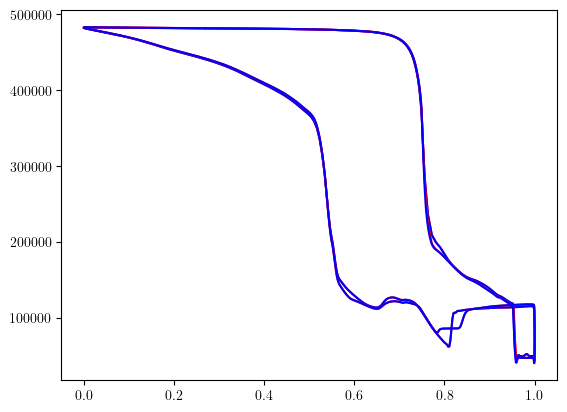

In [6]:
# %matplotlib widget

import scipy.interpolate as si

# ================
ii=0
# ================

# Move grid so it surrounds wall
nn_ = 151
g_ = 2
dn_ = np.array([n1*g_**i for i in range(nn_)])
n_ = np.cumsum(dn_)

# Compute local angle
theta_ = np.arctan(abs(nywall/nxwall))
for i,thet in enumerate(theta_):
    if nywall[i]<=0:
        theta_[i] = 2*np.pi-theta_[i]
    if nxwall[i]>=0 and nywall[i]>=0:
        theta_[i] = np.pi-theta_[i]
    if nxwall[i]>=0 and nywall[i]<=0:
        theta_[i] = 3*np.pi-theta_[i]
theta_ = np.pi-theta_

theta_,n_ = np.meshgrid(theta_,n_)
theta_ = theta_.T
n_ = n_.T
xw_ = comp_data[f'{ii}']['xw']*0.999+5e-4
yw_ = comp_data[f'{ii}']['yw']*0.999
xw_ = np.repeat(xw_[:,np.newaxis],nn_,axis=1)
yw_ = np.repeat(yw_[:,np.newaxis],nn_,axis=1)
x_new_ = xw_+n_/np.sqrt(1+np.tan(theta_)**2)
y_new_ = yw_+np.sqrt(n_**2-(x_new_-xw_)**2)
for i in range(nw):
    if nxwall[i]<=0 and nywall[i]>=0:
        x_new_[i] = xw_[i]-n_[i]/np.sqrt(1+np.tan(theta_[i])**2)
    if nxwall[i]<=0 and nywall[i]<=0:
        x_new_[i] = xw_[i]-n_[i]/np.sqrt(1+np.tan(theta_[i])**2)
        y_new_[i] = yw_[i]-np.sqrt(n_[i]**2-(x_new_[i]-xw_[i])**2)
    if nxwall[i]>=0 and nywall[i]<=0:
        y_new_[i] = yw_[i]-np.sqrt(n_[i]**2-(x_new_[i]-xw_[i])**2)
        
# Rearrange so new mesh starts at front stagnation point
# ind = 75 # LES
ind = ind_LE[0] # RANS
x_new_ = np.vstack((x_new_[ind:],x_new_[:ind]))
y_new_ = np.vstack((y_new_[ind:],y_new_[:ind]))
theta_ = np.vstack((theta_[ind:],theta_[:ind]))
n_ = np.vstack((n_[ind:],n_[:ind]))

        
# #=================
# # If pressure side
# #=================
# x_new_ = x_new_[::-1]
# y_new_ = y_new_[::-1]
# theta_ = theta_[::-1]
# n_ = n_[::-1]
# #=================


    
# Interpolate wall data
var_list_w = ['utau','muw','rhow','pw','tauw']
for var in var_list_w:
    for ii,dir_data in enumerate(dirs_data):
        # ii+=1
        comp_data[f'{ii}'][f'{var}_interp'] = si.griddata((np.repeat(comp_data[f'{ii}']['xw'][:,np.newaxis],5,axis=1).flatten(),\
                                                           np.repeat(comp_data[f'{ii}']['yw'][:,np.newaxis],5,axis=1).flatten()),\
                                                           np.repeat(comp_data[f'{ii}'][f'{var}'][:,np.newaxis],5,axis=1).flatten(),\
                                                           (x_new_[:,:5],y_new_[:,:5]),method='nearest')
        
        comp_data[f'{ii}'][f'{var}_interp'] = comp_data[f'{ii}'][f'{var}_interp'][:,0]
    print(var)

print('done')

plt.figure()
ii = 1
var = 'pw'
for ii in range(len(dirs_data)):
    plt.plot(x_new[:,0],comp_data[f'{ii}'][f'{var}_interp'],'r')
    plt.plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}'][f'{var}'],'b')
# plt.plot(x_new_[:,0],comp_data[f'{0}'][f'utau_interp'],'r')
plt.show()

# plt.figure()
# plt.plot(x_new_[:,:5],y_new_[:,:5],'r')
# plt.plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw'],'b')
# # plt.plot(x_new[:,],y_new[:,],'r')
# plt.show()

done


/tmp/ipykernel_332230/2152969902.py:77: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_new,y_new,comp_data[f'{ii}']['ut'],cmap='RdBu_r')


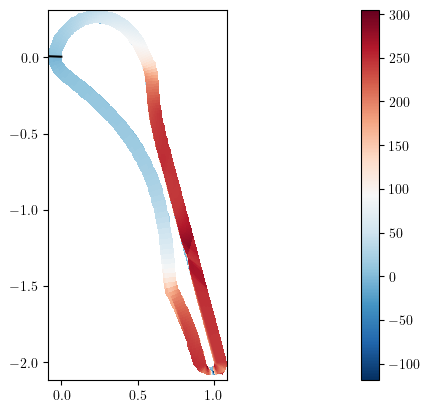

In [7]:
# %matplotlib widget
# %matplotlib auto
from scipy import signal

thetat = comp_data['theta']-np.pi/2 # tangent angle

for ii,dir_data in enumerate(dirs_data):

    # Tangential velocity
    comp_data[f'{ii}']['rhou_interp_'] = comp_data[f'{ii}']['rhou_interp'].copy()
    comp_data[f'{ii}']['rhov_interp_'] = comp_data[f'{ii}']['rhov_interp'].copy()
    rhout = comp_data[f'{ii}']['rhou_interp_']*np.cos(thetat)+\
            comp_data[f'{ii}']['rhov_interp_']*np.sin(thetat)
    comp_data[f'{ii}']['rhout'] = rhout
    comp_data[f'{ii}']['ut'] = rhout/comp_data[f'{ii}']['rho_interp']
    
    # # Friction
    # dux = comp_data[f'{ii}']['dux_interp']
    # duy = comp_data[f'{ii}']['duy_interp']
    # dvx = comp_data[f'{ii}']['dvx_interp']
    # dvy = comp_data[f'{ii}']['dvy_interp']
    # mu  = comp_data[f'{ii}']['mu_interp']
    # taut = 2*dux*(-np.sin(theta)) + (duy+dvx)*np.cos(theta)
    # comp_data[f'{ii}']['cf'] = -mu*taut/0.5/comp_data[f'{ii}']['rho_in']/comp_data[f'{ii}']['u_in']**2

    # Correct angle
    # start = 1750 # LES
    # start = 285 # RANS
    start = ind_TE[0]
    finish = -1
    comp_data[f'{ii}']['ut'][start:] = -comp_data[f'{ii}']['ut'][start:]
    # comp_data[f'{ii}']['cf'][start:] = -comp_data[f'{ii}']['cf'][start:]
    # start = 0
    # finish = 0 # LES
    # finish = 38 # RANS
    # comp_data[f'{ii}']['ut'][start:finish] = -comp_data[f'{ii}']['ut'][start:finish]
    
    # -y*Om_z/max(-y*Om_z) where the max is along each radial direction
    f = np.abs(np.nan_to_num(comp_data[f'{ii}']['omz_interp'],0))
    comp_data[f'{ii}']['yomz'] = n*f/np.repeat((n*f).max(axis=1)[:,np.newaxis],nn,axis=1)
            
#     # store
#     dyn_prs = 0.5*comp_data[f'{ii}']['rho_in']*comp_data[f'{ii}']['u_in']**2
#     tauw = -dvthetaRw*comp_data[f'{ii}']['mu_interp'][0,:]
#     comp_data[f'{ii}']['tauw'] = tauw
#     comp_data[f'{ii}']['cf'] = tauw/dyn_prs
#     comp_data[f'{ii}']['utau'] = np.sqrt(np.abs(tauw)/comp_data[f'{ii}']['rho_interp'][0,:])
    
#     # Entropy volumetric production rate
#     comp_data[f'{ii}']['dvthetaRw_p'] = comp_data[f'{ii}']['dvthetaRw']*\
#                                           comp_data[f'{ii}']['mu_interp'][0,:]/comp_data[f'{ii}']['tauw']
#     comp_data[f'{ii}']['uv_interp_p'] = comp_data[f'{ii}']['uv_interp']*\
#                                           comp_data[f'{ii}']['rho_interp'][0,:]/comp_data[f'{ii}']['tauw']
#     # with turbulent contribution
#     comp_data[f'{ii}']['Spppt_p'] = (comp_data[f'{ii}']['dvthetaRw_p']+comp_data[f'{ii}']['uv_interp_p'])*\
#                                        comp_data[f'{ii}']['dvthetaRw_p']
#     # only viscous dissipation
#     comp_data[f'{ii}']['Spppl_p'] = comp_data[f'{ii}']['dvthetaRw_p']**2
                                          
print('done')

# ii=2
# plt.figure()
# # plt.pcolormesh(xp_,yp_,comp_data[f'1']['Spppt_p'],cmap='RdBu_r')
# # plt.pcolormesh(xp_,yp_,comp_data[f'1']['yomz'],cmap='RdBu_r',vmin=0,vmax=1)
# plt.pcolormesh(x_new,y_new,comp_data[f'{ii}']['rhov_interp']/comp_data[f'{ii}']['rho_interp'],cmap='RdBu_r')
# # plt.pcolormesh(x_new,y_new,comp_data[f'{ii}']['rhou_interp']/comp_data[f'{ii}']['rho_interp'],vmin=-500,vmax=500,cmap='RdBu_r')
# # plt.xlim(0.92,1.05)
# # plt.ylim(-1.25,-1.15)
# plt.colorbar()
# # plt.axis('scaled')
# plt.show()

plt.figure()
# plt.pcolormesh(x_new[1000:1300],y_new[1000:1300],comp_data[f'{ii}']['rho_interp'][1000:1300],vmin=-500,vmax=500,cmap='RdBu_r')
# plt.pcolormesh(x_new[1000:1300],y_new[1000:1300],comp_data[f'{ii}']['ut'][1000:1300],cmap='RdBu_r')
plt.pcolormesh(x_new,y_new,comp_data[f'{ii}']['ut'],cmap='RdBu_r')
# plt.plot(x_new[400],y_new[400])
# plt.plot(x_new[500],y_new[500])
# plt.plot(x_new[750],y_new[750])
# plt.plot(x_new[1100],y_new[1100])
plt.plot(x_new[0],y_new[0],'k')
# plt.pcolormesh(x_new,y_new,n,cmap='RdBu_r')
# plt.xlim(0.92,1.05)
plt.ylim(-1.25,-1.15)
plt.colorbar()
plt.axis('scaled')
plt.show()

# Get BL height

- test using $\frac{\partial^2 u_t}{\partial r^2}\leq\epsilon$: worsk fine for front section but near separation becomes unreliable
- test with $-y\Omega_z=C$

65 0.006004882216623205 0.34976210791942147
BL height = 0.006004882216623205
40 0.0023298989257590475 0.0027542920799441847
BL height = 0.0023298989257590475


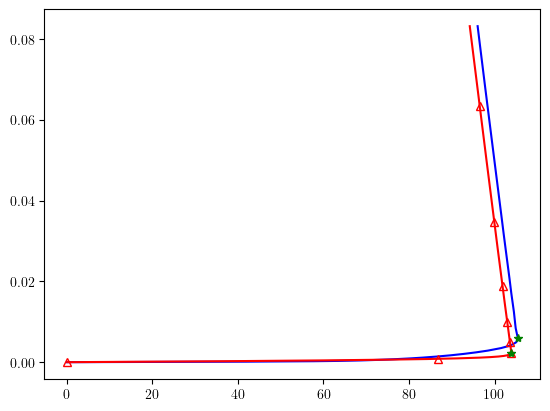

In [8]:
# %matplotlib widget

# Based on vorticity
pos = 50
C_om = 0.02
ii = 1

legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
styles  = ['-b','-^r','--k','-or']

plt.figure()

# Region of BL not too close to the wall
for ii,dir_data in enumerate(dirs_data):
    eps = 0.1
    eps_ = comp_data[f'{ii}']['ut'][pos,:]/comp_data[f'{ii}']['ut'][pos,:].max()
    ind_start = np.where(eps_>=eps)[0][0]
    # print(ind_start)

    bl = np.where(comp_data[f'{ii}']['yomz'][pos,ind_start:]<=C_om)[0][0]+ind_start
    
    x = comp_data[f'{ii}']['block_7']['x'][0,:]
    y = comp_data[f'{ii}']['block_7']['y'][0,:]
    n_old = np.sqrt((x[43]-x[0])**2 + (x[43]-x[0])**2)
    print(bl,n[pos,:][bl],n_old)
    print("BL height =",n[pos,:][bl])

    # om
    # plt.plot(comp_data[f'{ii}']['yomz'][pos,:],n[pos,:],'-b')
    # plt.plot(comp_data[f'{ii}']['yomz'][pos,:][bl],n[pos,:][bl],'*r')
# plt.plot(comp_data[f'{ii+1}']['yomz'][pos,:],n[pos,:],'--b')
# plt.plot(comp_data[f'{ii+1}']['yomz'][pos,:][bl],n[pos,:][bl],'*r')
# print(comp_data[f'{ii}']['yomz'][:,pos][bl])
    # ut
    plt.plot(comp_data[f'{ii}']['ut'][pos,:],n[pos,:],styles[ii],markerfacecolor='none',markevery=20)
    plt.plot(comp_data[f'{ii}']['ut'][pos,:][bl],n[pos,:][bl],'*g')

# plt.ylim(0.5,0.51)
plt.show()

In [9]:
# Based on vorticity (Griffin 2021)
C_om = 0.02

# Baumgartner (chaussette)
# ========================
# Near leading edge (top)
starts = [85,85,85,85,33,25]
stops = [1100,1100,1100,1100,295,295]
# Nozzle -> TE (top)
starts = [85,85,85,85]
stops = [1100,1100,1100,1100]
# Nozzle -> TE (top) with RANS mesh
starts = [38,38,38,50]
stops = [300,300,300,300]

# LS89 Mach17
# ===========
# Suction side
# ============
# Nozzle -> TE (top)
# starts = [150,150,150]
# stops = [1750,1750,1750]
starts = [0,0,0]
stops = [1750,1750,1750]
# RANS LES comp
# -------------
starts = [0,0,0]
stops = [250,250,1750]
# # Pressure side
# # =============
# start_PS = 1900
# stop_PS = 2550
# starts = [start_PS,start_PS,start_PS]
# stops = [stop_PS,stop_PS,stop_PS]

eps = 0.1

for ii,dir_data in enumerate(dirs_data):
    
    ut = comp_data[f'{ii}']['ut']
    rhout = comp_data[f'{ii}']['rhout']
    rho = comp_data[f'{ii}']['rho_interp']
    p = comp_data[f'{ii}']['p_interp']
    x = x_new.copy()

    # Storage
    delta_ = []
    delta_locs_ = []
    u_delta_ = []
    rhou_delta_ = []
    rho_delta_ = []
    p_delta_ = []
    x_delta_ = []
    start,stop = starts[ii],stops[ii]
    poss = np.arange(start,stop,1)
    for pos in poss:
        # print(pos)
        
        # Region of BL not too close to the wall
        eps_ = comp_data[f'{ii}']['ut'][pos,:]/comp_data[f'{ii}']['ut'][pos,:].max()
        ind_start = np.where(eps_>=eps)[0][0]

        delta_loc = np.where(comp_data[f'{ii}']['yomz'][pos,ind_start:]<=C_om)[0][0]+ind_start
        delta_.append(n[pos,:][delta_loc])
        u_delta_.append(ut[pos,:][delta_loc])
        rhou_delta_.append(rhout[pos,:][delta_loc])
        rho_delta_.append(rho[pos,:][delta_loc])
        p_delta_.append(p[pos,:][delta_loc])
        x_delta_.append(x[pos,:][delta_loc])
        delta_locs_.append(delta_loc)

    # Get arrays
    comp_data[f'{ii}']['delta'] = np.asarray(delta_)
    comp_data[f'{ii}']['delta_locs'] = np.asarray(delta_locs_)
    comp_data[f'{ii}']['u_delta'] = np.asarray(u_delta_)
    comp_data[f'{ii}']['rhou_delta'] = np.asarray(rhou_delta_)
    comp_data[f'{ii}']['rho_delta'] = np.asarray(rho_delta_)
    comp_data[f'{ii}']['p_delta'] = np.asarray(p_delta_)
    comp_data[f'{ii}']['x_delta'] = np.asarray(x_delta_)

print('done')

done


# Plot BL evolution

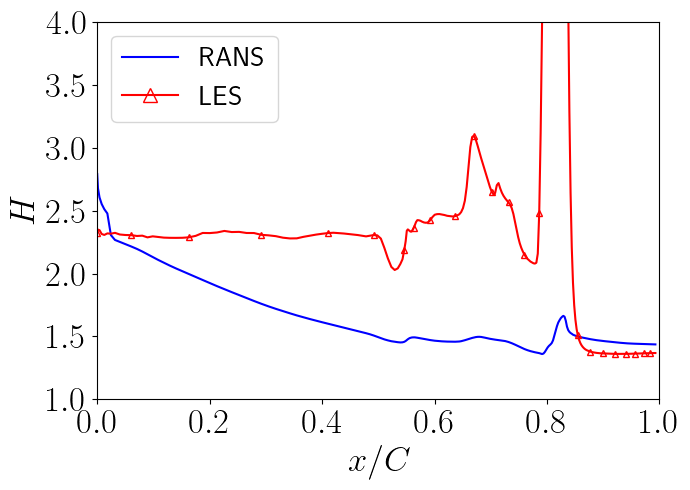

In [10]:
import scipy.integrate as sint
import scipy.signal as ss

# Plot hydro BL height evolution
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20

font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['RANS','LES','LES','RANS R134a','LES R134a']

N = 10

is_PS = False

plt.figure(figsize=(7,5))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    delta_locs = comp_data[f'{ii}']['delta_locs']
    start = starts[ii]
    stop  = stops[ii]

    # local Reynolds number
    # mu_in = comp_data[f'{ii}']['mu_in']
    # rho_in = comp_data[f'{ii}']['rho_in']
    # u_in = comp_data[f'{ii}']['u_in']
    # x_bl = theta_bl*np.pi/180*0.5*L_ref # dimensional equivalent FP BL location
    # Re_12 = np.sqrt((rho_in*u_in*x_bl/mu_in))
    # comp_data[f'{ii}']['Re_12'] = Re_12
    # Reynolds number based on displacement thickness
    ut = comp_data[f'{ii}']['ut'][start:stop,:]
    rhout = comp_data[f'{ii}']['rhout'][start:stop,:]
    u_delta = comp_data[f'{ii}']['u_delta']
    rhou_delta = comp_data[f'{ii}']['rhou_delta']
    rho_delta = comp_data[f'{ii}']['rho_delta']

    # BL height
    delta = comp_data[f'{ii}']['delta']
    if methods[ii]=='RANS':
        delta = np.convolve(delta,np.ones(N)/N,mode='same')
    comp_data[f'{ii}']['delta'] = delta
    
    # Displacement thickness
    rhou_delta = np.repeat(rhou_delta[:,np.newaxis],nn,axis=1)
    integrand = 1-rhout/rhou_delta
    delta_t_ = []
    for i,delta_loc in enumerate(delta_locs):
        delta_t_.append(np.sum(integrand[i,:delta_loc]*dn[:delta_loc]))
    delta_t = np.asarray(delta_t_)
    if methods[ii]=='RANS':
        delta_t = np.convolve(delta_t,np.ones(N)/N,mode='same')
    comp_data[f'{ii}']['delta_t'] = delta_t
    
    # Momentum thickness
    theta_t_ = []
    integrand = rhout/rhou_delta*(1-rhout/rhou_delta)
    for i,delta_loc in enumerate(delta_locs):
        theta_t_.append(np.sum(integrand[i,:delta_loc]*dn[:delta_loc]))
    theta_t = np.asarray(theta_t_)
    if methods[ii]=='RANS':
        theta_t = np.convolve(theta_t,np.ones(N)/N,mode='same')
    comp_data[f'{ii}']['theta_t'] = theta_t
    
    # Reynolds theta
    comp_data[f'{ii}']['Re_theta'] = comp_data[f'{ii}']['rhou_delta']*theta_t/comp_data[f'{ii}']['muw_interp'][start:stop]*L_refs[ii]
    
    # H factor
    H = delta_t/theta_t
    comp_data[f'{ii}']['H'] = H
    
    
    # 
    start = starts[ii]+ind_LE[0]
    stop  = stops[ii]+ind_LE[0]
    

    # if is_PS:
    #     plt.plot(s_ps[-stop:-start],H[::-1],styles[ii],markevery=10,\
    #              markersize=markersize,markerfacecolor='None',label=legends[ii])
    # else:
    #     plt.plot(s[start:stop],H,styles[ii],markevery=10,\
    #              markersize=markersize,markerfacecolor='None',label=legends[ii])
    plt.plot(xw[start:stop,0],H,styles[ii],markevery=10,\
             markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    # plt.plot(xw[start:stop-20,0],comp_data[f'{ii}']['delta'][:-20],styles[ii],markevery=10,\
    #          markersize=markersize,markerfacecolor='None',label=legends[ii])
    # plt.plot(xw[start:stop,0],comp_data[f'{ii}']['delta_t'],styles[ii],markevery=10,\
    #          markersize=markersize,markerfacecolor='None',label=legends[ii])
    # plt.plot(xw[start:stop,0],comp_data[f'{ii}']['theta_t'],styles[ii],markevery=10,\
    #          markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    # print(rhout)
    
    
plt.xlim(0,1)
plt.ylim(1,4)
# plt.xlim(-0.05,3)
# plt.ylim(1,4)
# plt.xlim(2.1,2.8)
# plt.ylim(1,3)
# plt.ylim(1,6)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
# plt.yticks([0.5,0.505,0.510,0.515,0.520],fontsize=font)
# plt.yticks([0.,0.005,0.010,0.015,0.020],fontsize=font)
plt.ylabel(r'$H$',fontsize=font)
# plt.ylabel(r'$\delta/c$',fontsize=font)
# plt.ylabel(r'$\delta^*/c$',fontsize=font)
# plt.ylabel(r'$\theta/c$',fontsize=font)
# plt.xlabel(r'$x/C$',fontsize=font)
plt.xlabel(r'$x/C$',fontsize=font)
plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/H.pdf',format='pdf')
# plt.savefig(f'Figures/ETMM_proceeding/delta.pdf',format='pdf')

# plt.savefig(f'Figures/ETMM_presentation/delta.pdf',format='pdf')

# plt.savefig(f'Figures/DLES14/H_x.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/H_s_zoom.pdf',format='pdf')
# plt.savefig(f'Figures/Manuscript/H_comp_RANS.pdf',format='pdf')

plt.show()


# Plot C_f

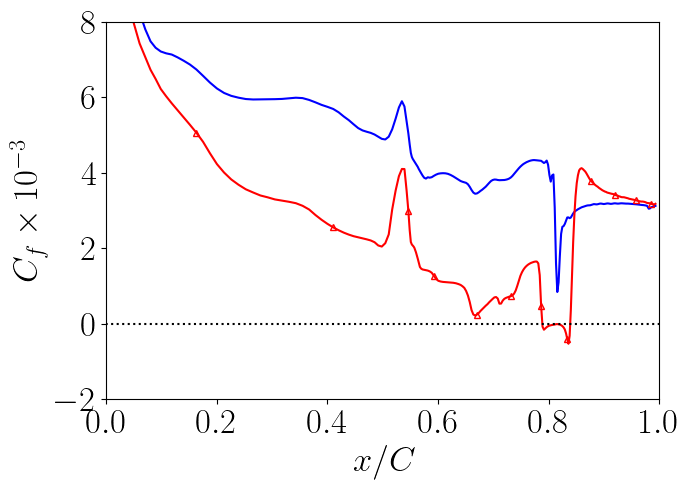

In [11]:
import scipy.integrate as sint
import scipy.signal as ss

# Plot hydro BL height evolution
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20

legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
styles  = ['-b','-^r','--k','-or']

N = 10

plt.figure(figsize=(7,5))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):

    start = starts[ii]
    stop  = stops[ii]
    
    # Recompute friction coefficient with local free stream quantities
    tauw = comp_data[f'{ii}']['tauw_interp']
    u_delta = comp_data[f'{ii}']['u_delta']
    rho_delta = comp_data[f'{ii}']['rho_delta']
    cf = tauw[start:stop]/(0.5*rho_delta*u_delta**2)
    comp_data[f'{ii}']['cf'] = cf
    
    start = starts[ii]+ind_LE[0]
    stop  = stops[ii]+ind_LE[0]

    plt.plot(xw[start:stop,0],cf/1e-3,styles[ii],markevery=markevery,\
             markersize=markersize,markerfacecolor='None',label=legends[ii])
    
plt.plot([-0.05,3],[0,0],':k')

plt.xlim(0,1)
plt.ylim(-2,8)
# Sci notation
# plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))

plt.xticks(fontsize=font)
plt.yticks([-2,0,2,4,6,8],fontsize=font)
plt.ylabel(r'$C_f\times10^{-3}$',fontsize=font)
plt.xlabel(r'$x/C$',fontsize=font)
# plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/H.pdf',format='pdf')
# plt.savefig(f'Figures/ETMM_proceeding/delta.pdf',format='pdf')

# plt.savefig(f'Figures/ETMM_presentation/delta.pdf',format='pdf')

# plt.savefig(f'Figures/DLES14/H_x.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/Cf_s.pdf',format='pdf')
# plt.savefig(f'Figures/Manuscript/Cf_comp_RANS.pdf',format='pdf')

plt.show()

# Plot C_f vs. Re_theta

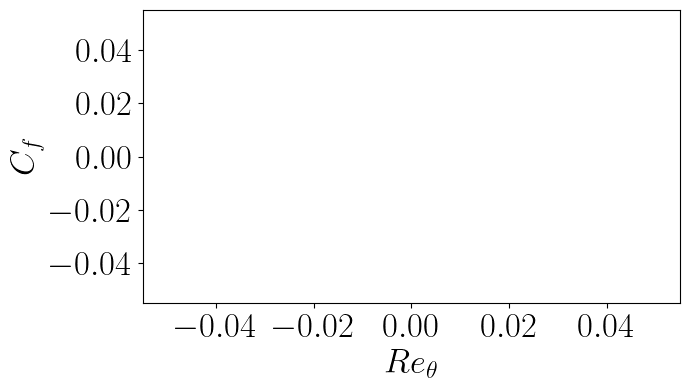

In [12]:
import scipy.integrate as sint
import scipy.signal as ss

# Plot hydro BL height evolution
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20

legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
styles  = ['-b','-^r','--k','-or']

N = 10

# Focus region
start_focus = 500
stop_focus = 1050

plt.figure(figsize=(7,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):

    start = starts[ii]
    stop  = stops[ii]

    # Friction coefficient
    cf = comp_data[f'{ii}']['cf'][start_focus:stop_focus]
    
    # Reynolds theta
    Re_theta = comp_data[f'{ii}']['Re_theta'][start_focus:stop_focus]

    plt.plot(Re_theta,cf,styles[ii],markevery=markevery,\
             markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    # plt.plot(s[start_focus:stop_focus],Re_theta,styles[ii],markevery=markevery,\
    #          markersize=markersize,markerfacecolor='None',label=legends[ii])

    
# plt.plot([-0.05,3],[0,0],':k')
# plt.xlim(-0.05,1.05)
# plt.xlim(-0.05,3)
# plt.ylim(-0.1,0.4)
# plt.ylim(1,6)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
# plt.yticks([0.5,0.505,0.510,0.515,0.520],fontsize=font)
# plt.yticks([0.,0.005,0.010,0.015,0.020],fontsize=font)
plt.ylabel(r'$C_f$',fontsize=font)
# plt.ylabel(r'$\delta/c$',fontsize=font)
# plt.ylabel(r'$\delta^*/c$',fontsize=font)
# plt.ylabel(r'$\theta/c$',fontsize=font)
# plt.xlabel(r'$x/C$',fontsize=font)
plt.xlabel(r'$Re_\theta$',fontsize=font)
# plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/H.pdf',format='pdf')
# plt.savefig(f'Figures/ETMM_proceeding/delta.pdf',format='pdf')

# plt.savefig(f'Figures/ETMM_presentation/delta.pdf',format='pdf')

# plt.savefig(f'Figures/DLES14/H_x.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/Cf_s.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/Cf_Retheta.pdf',format='pdf')

plt.show()

# Plot delta, delta_t, theta_t

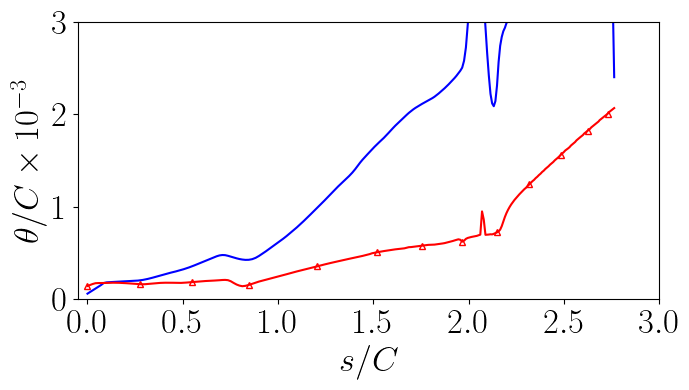

In [13]:
import scipy.integrate as sint
import scipy.signal as ss

# Plot hydro BL height evolution
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20

legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
styles  = ['-b','-^r','--k','-or']

N = 20

plt.figure(figsize=(7,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):

    start = starts[ii]
    stop  = stops[ii]
    
    delta = comp_data[f'{ii}']['delta']
    delta = np.convolve(delta,np.ones(N)/N,mode='same')
    delta_t = comp_data[f'{ii}']['delta_t']
    theta_t = comp_data[f'{ii}']['theta_t']
    
    # plt.plot(s[start:stop],delta,styles[ii],markevery=markevery,\
    #          markersize=markersize,markerfacecolor='None',label=legends[ii])    
    # plt.plot(s[start:stop],delta_t,styles[ii],markevery=markevery,\
    #          markersize=markersize,markerfacecolor='None',label=legends[ii])    
    plt.plot(s[start:stop],theta_t/1e-3,styles[ii],markevery=markevery,\
             markersize=markersize,markerfacecolor='None',label=legends[ii])

    
# plt.plot([-0.05,3],[0,0],':k')
# plt.xlim(-0.05,1.05)
plt.xlim(-0.05,3)
plt.ylim(0,3)
# plt.ylim(1,6)
plt.xticks(fontsize=font)
# plt.yticks([0,0.01,0.02,0.03],fontsize=font) # delta
plt.yticks([0,1,2,3],fontsize=font) # delta_t
# plt.ylabel(r'$\delta^*/C$',fontsize=font)
plt.ylabel(r'$\theta/C\times10^{-3}$',fontsize=font)
plt.xlabel(r'$s/C$',fontsize=font)
# plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/H.pdf',format='pdf')
# plt.savefig(f'Figures/ETMM_proceeding/delta.pdf',format='pdf')

# plt.savefig(f'Figures/ETMM_presentation/delta.pdf',format='pdf')

# plt.savefig(f'Figures/DLES14/H_x.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/delta_s.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/delta_t_s.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/theta_t_s.pdf',format='pdf')

plt.show()

# Double figure: $C_f$ \& $H$

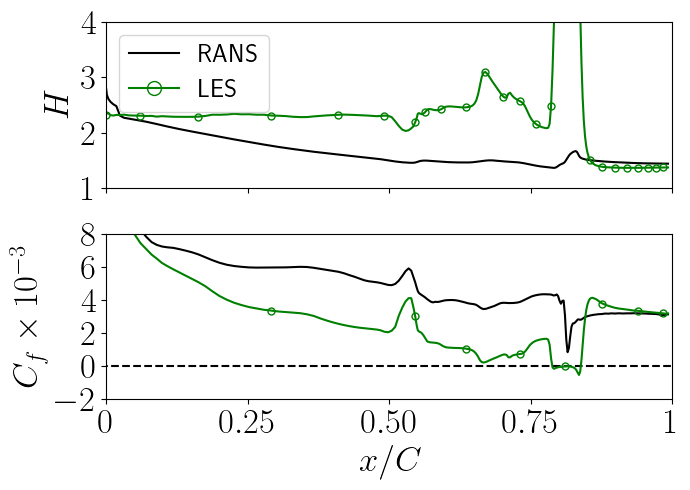

In [14]:
# import scipy.integrate as sint
import scipy.signal as ss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# # Baumgartner (chaussette)
# # =======================
# starts = [38,38,38,50]
# stops = [300,300,300,300]

# # LS89 Mach17
# # ===========]
# # Nozzle -> TE (top)
# starts = [0,0,0]
# stops = [1750,1750,1750]

font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['RANS','LES','LES','RANS R134a','LES R134a']
styles  = ['-k','-og']
# styles  = ['-ob','-.b','-or','-.r']
# styles  = ['-.r','-or','-.b','-^b']
# styles  = ['-.b','-^b']

fig,axs = plt.subplots(2,1,figsize=(7,5),sharex=True,sharey=False)
# plt.figure()
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    delta_locs = comp_data[f'{ii}']['delta_locs']
    start = starts[ii]+ind_LE[0]
    stop  = stops[ii]+ind_LE[0]

    H = comp_data[f'{ii}']['H']
    cf = comp_data[f'{ii}']['cf']

    axs[0].plot(xw[start:stop,0],H,styles[ii],markevery=10,\
                 markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    axs[1].plot(xw[start:stop,0],cf,styles[ii],markevery=30,\
                 markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    # ticks
    if ii==0:
        axs[0].set_ylim(1,4)
        axs[0].set_ylabel(r'$H$',fontsize=font)
        axs[0].set_yticks([1,2,3,4])
        axs[0].set_xticklabels([])
        axs[0].set_yticklabels([r'$1$',r'$2$',r'$3$',r'$4$'],fontsize=font)
        
        axs[1].set_ylim(-0.002,0.008)
        axs[1].set_xlabel(r'$x/C$',fontsize=font)
        axs[1].set_ylabel(r'$C_f\times10^{-3}$',fontsize=font)
        axs[1].set_xticks([0,0.25,0.5,0.75,1])
        # axs[1].set_yticks([0,0.1,0.2,0.3])
        axs[1].set_yticks([-0.002,0.0,0.002,0.004,0.006,0.008])
        axs[1].set_xticklabels([r'$0$',r'$0.25$',r'$0.50$',r'$0.75$',r'$1$'],fontsize=font)
        # axs[1].set_yticklabels([r'$0$',r'$0.1$',r'$0.2$',r'$0.3$'],fontsize=font)
        axs[1].set_yticklabels([r'$-2$',r'$0$',r'$2$',r'$4$',r'$6$',r'$8$'],fontsize=font)
        
        axs[1].plot([-0.05,1.05],[0,0],'--k')
        
    # if ii==2:
    #     axs[0].legend(prop={'size':font-10},markerscale=markerscale)
plt.xlim(0,1)
plt.tight_layout()
        
# # Inset plot
# axi = inset_axes(axs[1], width=1.2, height=0.6, bbox_to_anchor=(0.5,0.97,-0.02,0),bbox_transform=axs[1].transAxes)
# for ii,dir_data in enumerate(dirs_data):
#     plt.plot(comp_data[f'{ii}']['xw'][ind_LE[ii]:ind_TE[ii]],comp_data[f'{ii}']['cf'][ind_LE[ii]:ind_TE[ii]],\
#              styles[ii],linewidth=lw,markevery=10,markersize=markersize,markerfacecolor='none',\
#              label=legends[ii])

# plt.plot([-0.05,1.05],[0,0],'--k')
# plt.xticks([0,0.3],fontsize=font-5)
# plt.yticks([0,0.03],fontsize=font-5)
# plt.xlim(0,0.3)
# plt.ylim(-1e-2,0.03)
    
axs[0].legend(prop={'size':font-7},markerscale=markerscale)

# plt.savefig(f'Figures/ETMM_presentation/delta.pdf',format='pdf')
# plt.savefig(f'Figures/ETMM_presentation/H.pdf',format='pdf')
# plt.savefig(f'Figures/ASME/H_Cf.pdf',format='pdf')
# plt.savefig(f'Figures/NICFD5/H_Cf.pdf',format='pdf')

plt.show()

# Compute Clauser pressure gradient parameter

In [121]:

font = 25
markerscale=2
lw=1.3
markersize=5
markevery=30

legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
styles  = ['-b','-^r','--k','-or']

plt.figure(figsize=(7,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    # # Compute pressure derivative
    # # ===========================
    # N = 10 # smooth
    # # off-centered
    # # ------------
    # # Get x-coord spacings
    # # xi = comp_data[f'{ii}']['x_delta']
    # xi = x_new[starts[ii]:stops[ii],0]
    # xi = s[starts[ii]:stops[ii]]
    # dxip1 = xi[1:-1]-xi[:-2]
    # dxip2 = xi[2:]-xi[1:-1]
    # dx = -3*dxip1 + dxip2
    # # Get pressure spacing
    # pi = comp_data[f'{ii}']['p_delta'][:-2]
    # pip1 = comp_data[f'{ii}']['p_delta'][1:-1]
    # pip2 = comp_data[f'{ii}']['p_delta'][2:]
    # dp = 3*pi - 4*pip1 + pip2
    # dpdx = dp/dx/L_ref
    # comp_data[f'{ii}']['dpdx_delta'] = dpdx
    # # # dpdx = np.convolve(dpdx,np.ones(N)/N,mode='same')
    # # plt.plot(xi[:-2],dpdx,styles[ii],markevery=markevery,markerfacecolor='none')
    
    # centered
    # --------
    # Get x-coord spacings
    # xi = comp_data[f'{ii}']['x_delta']
    xi = s[starts[ii]:stops[ii]]
    dxim1 = xi[1:-1]-xi[:-2]
    dxip1 = xi[2:]-xi[1:-1]
    dx = dxip1+dxim1
    # Get pressure spacing
    # pim1 = comp_data[f'{ii}']['p_delta'][:-2]
    # pip1 = comp_data[f'{ii}']['p_delta'][2:]
    pim1 = comp_data[f'{ii}']['p_interp'][starts[ii]:stops[ii]][:-2,0]
    pip1 = comp_data[f'{ii}']['p_interp'][starts[ii]:stops[ii]][2:,0]
    dp = pip1-pim1
    dpdx = dp/dx/L_ref
    comp_data[f'{ii}']['dpdx_delta'] = dpdx
    # dpdx = np.convolve(dpdx,np.ones(N)/N,mode='same')
    # plt.plot(xi[1:-1],dpdx,styles[ii],markevery=markevery,markerfacecolor='none')
    
    # # 1st-order
    # # ---------
    # # Get x-coord spacings
    # xi = s[starts[ii]:stops[ii]][:-1]
    # xip1 = s[starts[ii]:stops[ii]][1:]
    # dx = xip1-xi
    # # Get pressure spacing
    # pi = comp_data[f'{ii}']['p_delta'][:-1]
    # pip1 = comp_data[f'{ii}']['p_delta'][1:]
    # dp = pip1-pi
    # dpdx = dp/dx/L_ref
    # comp_data[f'{ii}']['dpdx_delta'] = dpdx
    # # dpdx = np.convolve(dpdx,np.ones(N)/N,mode='same')
    # # plt.plot(xi,dpdx,styles[ii],markevery=markevery,markerfacecolor='none')
    # # plt.plot(xi,pi,styles[ii],markevery=markevery,markerfacecolor='none')
    
    # Clauser parameter
    # =================
    tauw = comp_data[f'{ii}']['tauw_interp'][starts[ii]:stops[ii]][1:-1]
    delta_t = comp_data[f'{ii}']['delta_t'][1:-1]*L_ref
    beta = dpdx*delta_t/tauw
    # beta = np.convolve(beta,np.ones(N)/N,mode='same')
    comp_data[f'{ii}']['beta'] = beta
    comp_data[f'{ii}']['x_beta'] = xi[1:-1]
    
    # Plot
    # ====
    plt.plot(xi[1:-1],beta,styles[ii],markevery=markevery,markerfacecolor='none',label=legends[ii])

plt.plot([-0.05,3],[0,0],':k')
plt.xlim(0,3)
plt.ylim(-2,1)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.ylabel(r'$\beta$',fontsize=font)
plt.xlabel(r'$s/C$',fontsize=font)
# plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig(f'Figures/DLES14/beta_s.pdf',format='pdf')

plt.show()

# Zoom on turbulent region
# ========================
plt.figure(figsize=(7,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    beta = comp_data[f'{ii}']['beta']
    xi = comp_data[f'{ii}']['x_beta']
        
    # Plot
    # ====
    plt.plot(xi,beta,styles[ii],markevery=markevery,markerfacecolor='none',label=legends[ii])

plt.plot([-0.05,3],[0,0],':k')
plt.xlim(2.1,2.8)
plt.ylim(-0.1,0.3)
plt.xticks(fontsize=font)
plt.yticks([-0.1,0,0.1,0.2,0.3],fontsize=font)
plt.ylabel(r'$\beta$',fontsize=font)
plt.xlabel(r'$s/C$',fontsize=font)
# plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig(f'Figures/DLES14/beta_s_zoom.pdf',format='pdf')

plt.show()

ValueError: operands could not be broadcast together with shapes (398,) (248,) 

<Figure size 700x400 with 0 Axes>

# Plot 3 subplots with Clauser (ASME)

1.5331035737381076


ValueError: x and y must have same first dimension, but have shapes (1700,) and (1750,)

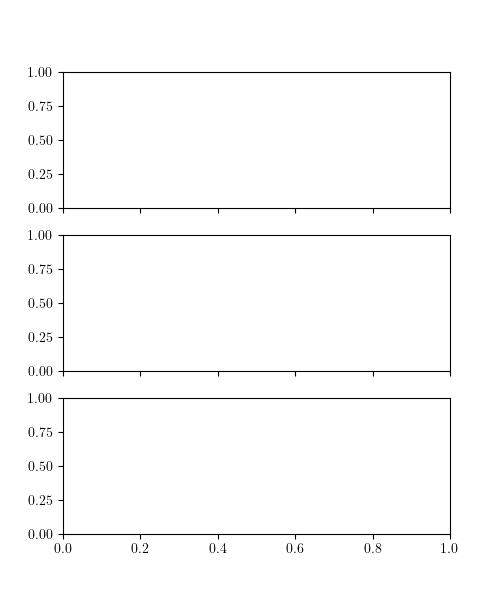

In [16]:
# import scipy.integrate as sint
import scipy.signal as ss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Baumgartner (chaussette)
# =======================
starts = [38,38,38,50]
stops = [300,300,300,300]

# LS89 Mach17
# ===========]
# Nozzle -> TE (top)
starts = [150]
stops = [1850]

font = 20
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['RANS','DDES','LES','RANS R134a','LES R134a']
# styles  = ['-ob','-.b','-or','-.r']
# styles  = ['-.r','-or','-.b','-^b']
# styles  = ['-.b','-^b']

fig,axs = plt.subplots(3,1,figsize=(5,6),sharex=True,sharey=False)
# plt.figure()
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    delta_locs = comp_data[f'{ii}']['delta_locs']
    start = starts[ii]
    stop  = stops[ii]

    H = comp_data[f'{ii}']['H']
    print(H[-1])
    cf = comp_data[f'{ii}']['cf']

    axs[0].plot(xw[start:stop,0],H,styles[ii],markevery=10,\
                 markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    axs[1].plot(comp_data[f'{ii}']['x_beta'],comp_data[f'{ii}']['beta'],styles[ii],markevery=30,\
                 markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    axs[2].plot(comp_data[f'{ii}']['xw'][ind_LE[ii]:ind_TE[ii]],cf[ind_LE[ii]:ind_TE[ii]],styles[ii],markevery=30,\
                 markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    # ticks
    if ii==0:
        axs[0].set_ylim(1,4)
        axs[0].set_ylabel(r'$H$',fontsize=font)
        axs[0].set_yticks([1,2,3,4])
        axs[0].set_xticklabels([])
        axs[0].set_yticklabels([r'$1$',r'$2$',r'$3$',r'$4$'],fontsize=font)
        
        axs[1].set_ylim(-3,6)
        axs[1].set_ylabel(r'$\beta$',fontsize=font)
        # axs[1].set_xticks([0,0.25,0.5,0.75,1])
        axs[1].set_yticks([-3,0,3,6])
        # axs[1].set_xticklabels([r'$0$',r'$0.25$',r'$0.50$',r'$0.75$',r'$1$'],fontsize=font)
        axs[1].set_yticklabels([r'$-3$',r'$0$',r'$3$',r'$6$'],fontsize=font)
        axs[1].plot([-0.05,1.05],[0,0],'--k')
        
        axs[2].set_ylim(-0.05,0.35)
        axs[2].set_xlabel(r'$x/C$',fontsize=font)
        axs[2].set_ylabel(r'$C_f$',fontsize=font)
        axs[2].set_xticks([0,0.25,0.5,0.75,1])
        axs[2].set_yticks([0,0.1,0.2,0.3])
        axs[2].set_xticklabels([r'$0$',r'$0.25$',r'$0.50$',r'$0.75$',r'$1$'],fontsize=font)
        axs[2].set_yticklabels([r'$0$',r'$0.1$',r'$0.2$',r'$0.3$'],fontsize=font)
        axs[2].plot([-0.05,1.05],[0,0],'--k')

    # if ii==2:
    #     axs[0].legend(prop={'size':font-10},markerscale=markerscale)
plt.xlim(0,1)
plt.tight_layout()
        
# Inset plot
axi = inset_axes(axs[1], width=1.2, height=0.6, bbox_to_anchor=(0.5,-0.3,-0.02,0),bbox_transform=axs[1].transAxes)
for ii,dir_data in enumerate(dirs_data):
    plt.plot(comp_data[f'{ii}']['xw'][ind_LE[ii]:ind_TE[ii]],comp_data[f'{ii}']['cf'][ind_LE[ii]:ind_TE[ii]],\
             styles[ii],linewidth=lw,markevery=10,markersize=markersize,markerfacecolor='none',\
             label=legends[ii])

plt.plot([-0.05,1.05],[0,0],'--k')
# plt.xticks([0,0.3],fontsize=font-5)
# plt.yticks([0,0.03],fontsize=font-5)
# plt.xlim(0,0.3)
# plt.ylim(-1e-2,0.03)
plt.xticks([0.75,0.85],fontsize=font-5)
plt.yticks([0,0.1],fontsize=font-5)
plt.xlim(0.75,0.85)
plt.ylim(-1e-1,0.1)

axs[0].legend(prop={'size':font-7},markerscale=markerscale)

# plt.savefig(f'Figures/ETMM_presentation/delta.pdf',format='pdf')
# plt.savefig(f'Figures/ETMM_presentation/H.pdf',format='pdf')
# plt.savefig(f'Figures/ASME/H_Cf.pdf',format='pdf')

plt.show()

# Plot edge velocity evolution

22.77884158033973 -0.10525980288343871 219.9871038574986


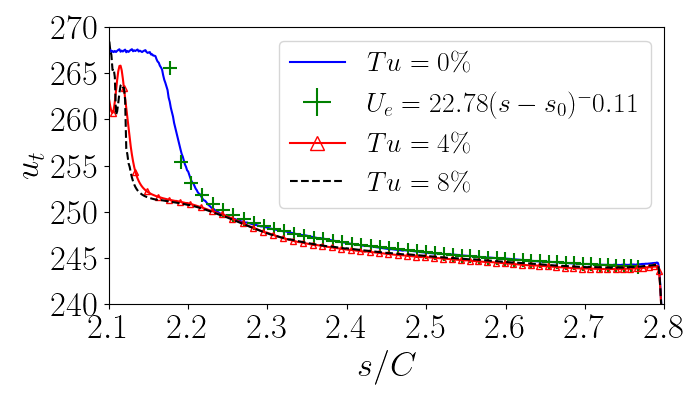

In [17]:
import scipy.integrate as sint
import scipy.signal as ss
from scipy.optimize import curve_fit

# Plot hydro BL height evolution
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20

legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
styles  = ['-b','-^r','--k','-or']

# LS89 Mach17
# ===========]
# Nozzle -> TE (top)
starts = [0,0,0]
stops = [1750,1750,1750]

N = 10

# For velocity power law
start_power = 1180
stop_power = 1700
s0 = s[start_power]
def func_powerlaw(x,a,b,c):
    return a * x**b + c

plt.figure(figsize=(7,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    start = starts[ii]
    stop  = stops[ii]

    # Reynolds number based on displacement thickness
    u_delta = comp_data[f'{ii}']['u_delta'][start:stop]

    plt.plot(s[start:stop],u_delta,styles[ii],markevery=10,\
             markersize=markersize,markerfacecolor='None',label=legends[ii])
    
    if ii==0:
        # Add power law velocity profile
        popt,pcov = curve_fit(func_powerlaw,s[start_power+1:stop_power]-s0,u_delta[start_power+1:stop_power],\
                              p0=np.asarray([0,0,0]),\
                              bounds=(np.array([-1e10,-1e10,0]),np.array([1e10,0,1e10])),maxfev=10000)
        a,b,c = popt
        print(a,b,c)
        u_power = func_powerlaw(s[start_power+1:stop_power]-s0,a,b,c)
        plt.plot(s[start_power+1:stop_power],u_power,'+g',linewidth=5,\
                 markevery=10,markersize=10,markeredgewidth=1.5,label=fr'$U_e={round(a,2)}(s-s_0)^{round(b,2)}$')
    
plt.xlim(2.1,2.8)
plt.ylim(240,270)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
# plt.yticks([0.5,0.505,0.510,0.515,0.520],fontsize=font)
# plt.yticks([0.,0.005,0.010,0.015,0.020],fontsize=font)
plt.ylabel(r'$u_t$',fontsize=font)
# plt.ylabel(r'$\delta/c$',fontsize=font)
# plt.ylabel(r'$\delta^*/c$',fontsize=font)
# plt.ylabel(r'$\theta/c$',fontsize=font)
# plt.xlabel(r'$x/C$',fontsize=font)
plt.xlabel(r'$s/C$',fontsize=font)
plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/H.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/H.pdf',format='pdf')
# plt.savefig(f'Figures/ETMM_proceeding/delta.pdf',format='pdf')

# plt.savefig(f'Figures/ETMM_presentation/delta.pdf',format='pdf')

# plt.savefig(f'Figures/DLES14/H_x.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/u_delta_s.pdf',format='pdf')

plt.show()

# Test power law

22.778899458858575 -0.10525959180032696 219.98704483162143


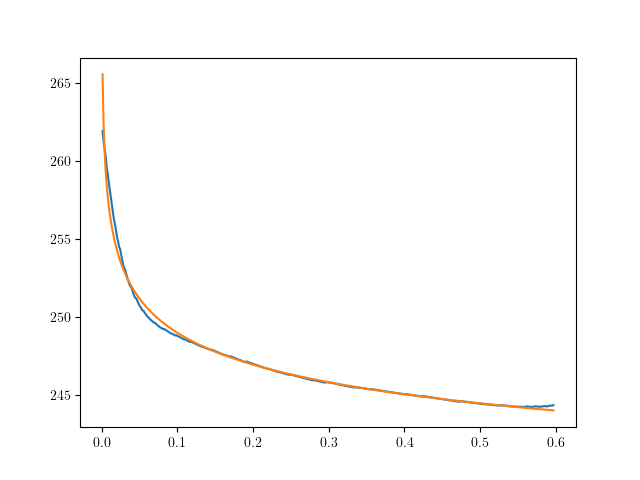

In [18]:
u_test = u_delta = comp_data[f'{0}']['u_delta'][start_power+1:stop_power]

popt,pcov = curve_fit(func_powerlaw,s[start_power+1:stop_power]-s0,u_test,\
                      p0=np.asarray([243,-0.01,0]),\
                      bounds=(np.array([-1e10,-1e10,0]),np.array([1e10,0,1e10])),maxfev=10000)
a,b,c = popt
print(a,b,c)
u_power = func_powerlaw(s[start_power+1:stop_power]-s0,a,b,c)

plt.figure()
plt.plot(s[start_power+1:stop_power]-s0,u_test)
plt.plot(s[start_power+1:stop_power]-s0,u_power)
plt.show()


# Get back pressure coefficient

/tmp/ipykernel_2579348/2113720156.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(comp_data[f'{ii}'][f'block_6']['x'],comp_data[f'{ii}'][f'block_6']['y'],ut)


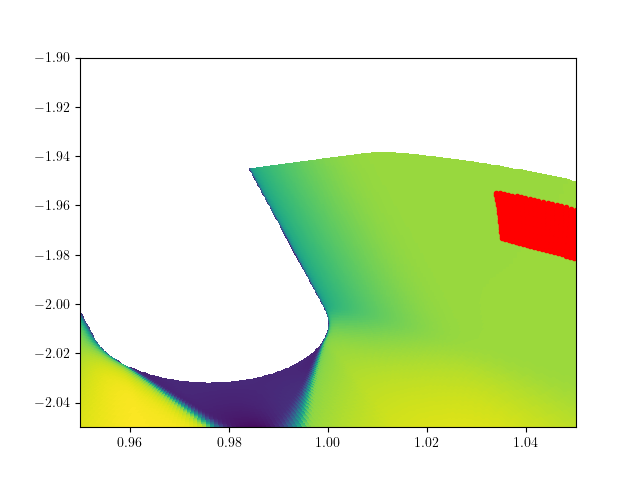

In [19]:
# %matplotlib widget

ii=2

thet = 75*np.pi/180
ut = comp_data[f'{ii}'][f'block_6']['u']*np.cos(thet) -\
     comp_data[f'{ii}'][f'block_6']['v']*np.sin(thet)

# LES
x1 = 10
x2 = 30
y1 = 180
y2 = 200

# # DES
# x1 = 30
# x2 = 50
# y1 = 80
# y2 = 100

# # RANS
# x1 = 0
# x2 = 10
# y1 = 45
# y2 = 50

# x1 = 10
# x2 = 30
# y1 = 0
# y2 = 1

plt.figure()
plt.pcolormesh(comp_data[f'{ii}'][f'block_6']['x'],comp_data[f'{ii}'][f'block_6']['y'],ut)
plt.plot(comp_data[f'{ii}'][f'block_6']['x'][x1:x2,y1:y2],comp_data[f'{ii}'][f'block_6']['y'][x1:x2,y1:y2],'.r')
plt.xlim(0.95,1.05)
plt.ylim(-2.05,-1.9)
# plt.axis('scaled')
plt.show()

# Get reference quantities DLES14

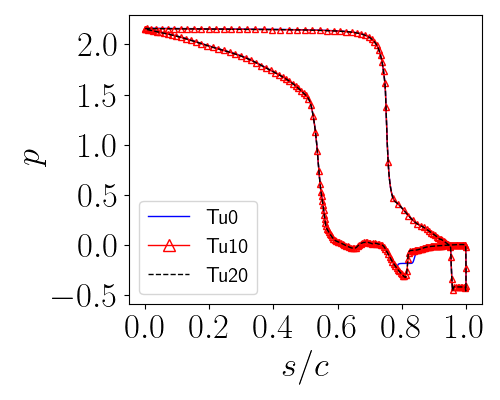

In [20]:
# %matplotlib widget

font = 25
markerscale=2
legends = ['Tu0','Tu10','Tu20','LES R134a']

# Get reference values
# ====================
var = 'p'
x1s = [10,10,10]
x2s = [30,30,30]
y1s = [180,180,180]
y2s = [200,200,200]


uref = []
roref = []
pref = []
for ii,dir_data in enumerate(dirs_data):
#     plt.figure(figsize=(7,4))
#     plt.rcParams['text.usetex'] = True
#     for bl in range(n_bl):
#         bl+=1
#         plt.pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
#                        comp_data[f'{ii}'][f'block_{bl}']['y'],\
#                        comp_data[f'{ii}'][f'block_{bl}'][var],\
#                        vmin=7e4,vmax=8e5,cmap='RdBu_r')

#     plt.xlabel(r'$x/c$',fontsize=font)
#     plt.ylabel(r'$y/c$',fontsize=font)
#     plt.xticks(fontsize=font)
#     plt.yticks(fontsize=font)
#     plt.xlim(0.95,1.05)
#     plt.ylim(-0.25,-0.15)
    
#     # Spatial average

    x1,x2 = x1s[ii],x2s[ii]
    y1,y2 = y1s[ii],y2s[ii]
#     plt.pcolormesh(comp_data[f'{ii}'][f'block_6']['x'][x1:x2,y1:y2],\
#                    comp_data[f'{ii}'][f'block_6']['y'][x1:x2,y1:y2],\
#                    comp_data[f'{ii}'][f'block_6']['p'][x1:x2,y1:y2],cmap='binary')    
#     plt.colorbar()
#     plt.tight_layout()
#     # plt.savefig('Figures_LS59_Stefan/Mis_wall_mesh_convergence.pdf',format='pdf')
#     plt.show()
    
    # Compute reference quantities
    thet = 75*np.pi/180
    uref_ = comp_data[f'{ii}'][f'block_6']['u'][x1:x2,y1:y2]*np.cos(thet) -\
            comp_data[f'{ii}'][f'block_6']['v'][x1:x2,y1:y2]*np.sin(thet)
    uref.append(np.mean(uref_))
    roref.append(np.mean(comp_data[f'{ii}'][f'block_6']['rho'][x1:x2,y1:y2]))
    pref.append(np.mean(comp_data[f'{ii}'][f'block_6']['p'][x1:x2,y1:y2]))


# Denton definition of Cp
# =======================

plt.figure(figsize=(5,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
        
    plt.plot(comp_data[f'{ii}']['xw'],(comp_data[f'{ii}']['pw']-pref[ii])/0.5/roref[ii]/uref[ii]**2,\
            styles[ii],linewidth=1,markevery=10,markersize=4,markerfacecolor='none',\
             label=legends[ii])

# Exp data
# plt.plot(x,Mis_sanz,'sk',markerfacecolor='None')
plt.xlabel(r'$s/c$',fontsize=font)
plt.ylabel(r'$p$',fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.legend(prop={'size':font-10},markerscale=markerscale)
plt.tight_layout()
# plt.savefig('Figures_LS59_Stefan/Mis_wall_mesh_convergence.pdf',format='pdf')
plt.show()

# Loss coeff DLES14

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[1.4179966393137964, 1.4453315142885204, 1.438497795544839] [0.2868165644187852, 0.3473008823556308, 0.36919645715288274] [0.13038706425054195, 0.13333681310185086, 0.13450918684807864]


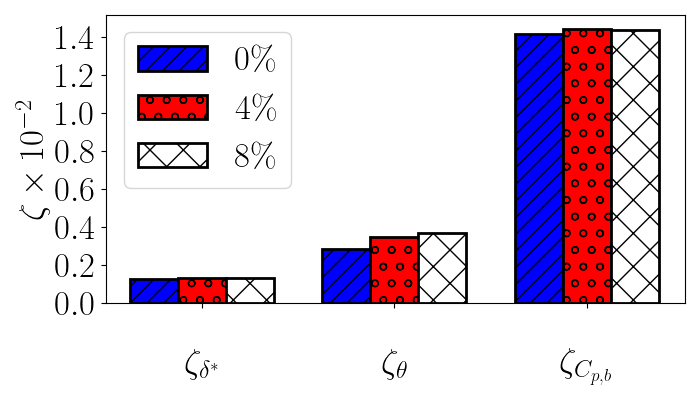

In [34]:
%matplotlib widget

Cpbs = [0.415,0.423,0.421]
t = 5e-2 # T.E thickness
ind = -30

bp = []
mom = []
blo = []
for ii,dir_data in enumerate(dirs_data):
    
    delta_t = comp_data[f'{ii}']['delta_t']
    theta_t = comp_data[f'{ii}']['theta_t']
    zeta = Cpbs[ii]*t/pitch + 2*theta_t[ind]/pitch + (delta_t[ind]+t)**2/pitch**2
    comp_data[f'{ii}']['zeta'] = zeta

    # Normalized
    # bp.append(Cpbs[ii]*t/pitch/zeta)
    # mom.append(2*theta_t[ind]/pitch/zeta)
    # blo.append((delta_t[ind]+t)**2/pitch**2/zeta)
    
    # Non-normalized
    bp.append(Cpbs[ii]*t/pitch)
    mom.append(2*theta_t[ind]/pitch)
    blo.append((delta_t[ind]+t)**2/pitch**2)
    
    # x 10^-2
    bp[ii] = bp[ii]*1e2
    mom[ii] = mom[ii]*1e2
    blo[ii] = blo[ii]*1e2
print(bp,mom,blo)
    
font=25
markerscale=2
markersize=8
markevery=5
width=1
lw=1.3

fig,ax = plt.subplots(figsize=(7,4))
plt.rcParams['text.usetex'] = True

hatchs = ["//","o","x"]
styles  = ['-b','-^r','--k','-or']

# Blockage
offset = 0
j = 0
for i in range(len(dirs_data)):
    i+=1
    if styles[j][-1]=='k':
        plt.bar(i,blo[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=(hatchs[j]))
    else:
        plt.bar(i,blo[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=(hatchs[j]))
    j+=1
    
# Momentum
offset = 3
j = 0
for i in range(len(dirs_data)):
    i+=2
    i+=offset
    if styles[j][-1]=='k':
        plt.bar(i,mom[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=(hatchs[j]))
    else:
        plt.bar(i,mom[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=(hatchs[j]))
    j+=1
    
# Back pressure
offset = 6
j = 0
for i in range(len(dirs_data)):
    i+=3
    i+=offset
    if styles[j][-1]=='k':
        plt.bar(i,bp[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=(hatchs[j]))
    else:
        plt.bar(i,bp[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=(hatchs[j]))
    j+=1

plt.xticks([2,6,10],['\n'+r'$\zeta_{\delta^*}$','\n'+r'$\zeta_\theta$','\n'+r'$\zeta_{C_{p,b}}$'],fontsize=font)

plt.yticks(fontsize=font)
plt.ylabel(r'$\zeta\times10^{-2}$',fontsize=font)
# plt.ylim(0,0.008)
plt.xlim(0,)

# Legends
plt.bar(-5,0,width=width,linewidth=2,fill=True,facecolor='b',edgecolor='black',hatch=("//"),label=r'$0\%$')
plt.bar(-5,0,width=width,linewidth=2,fill=True,facecolor='r',edgecolor='black',hatch=("o"),label=r'$4\%$')
plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("x"),label=r'$8\%$')


# # Blockage
# offset = 0
# j = 0
# for i in range(len(dirs_data)):
#     i+=1
#     i+=offset
#     if styles[j][-1]=='k':
#         plt.bar(i,blo[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=("///"))
#     else:
#         plt.bar(i,blo[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=("///"))
#     offset+=3
#     j+=1
    
# # Momentum
# offset = 0
# j = 0
# for i in range(len(dirs_data)):
#     i+=2
#     i+=offset
#     if styles[j][-1]=='k':
#         plt.bar(i,mom[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=("oo"))
#     else:
#         plt.bar(i,mom[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=("oo"))
#     offset+=3
#     j+=1
    
# # Back pressure
# offset = 0
# j = 0
# for i in range(len(dirs_data)):
#     i+=3
#     i+=offset
#     if styles[j][-1]=='k':
#         plt.bar(i,bp[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=("xx"))
#     else:
#         plt.bar(i,bp[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=("xx"))
#     offset+=3
#     j+=1




# plt.xticks([2,6,10],[r'$0\%$',r'$4\%$',r'$8\%$'],fontsize=font)


# plt.yticks(fontsize=font)
# plt.ylabel(r'$\zeta$',fontsize=font)
# # plt.ylim(0,0.008)
# plt.xlim(0,)

# # # Annotations
# # # -----------
# # # RANS
# # plt.annotate(r'$8\%$' ,(0.5,0.001),fontsize=font-5)
# # plt.annotate(r'$42\%$',(1.3,0.0045),fontsize=font-5)
# # plt.annotate(r'$50\%$',(2.5,0.0052),fontsize=font-5)
# # # DES
# # plt.annotate(r'$7\%$' ,(4.5,0.001),fontsize=font-5)
# # plt.annotate(r'$36\%$',(5.3,0.0043),fontsize=font-5)
# # plt.annotate(r'$57\%$',(6.6,0.0065),fontsize=font-5)
# # # LES
# # plt.annotate(r'$7\%$' ,(8.5,0.001),fontsize=font-5)
# # plt.annotate(r'$22\%$',(9.3,0.0024),fontsize=font-5)
# # plt.annotate(r'$71\%$',(10.6,0.0068),fontsize=font-5)


# # plt.plot([6,6],[0,1.15],'--k')
# # plt.annotate(r'Air',(2,1.05),fontsize=font)
# # plt.annotate(r'R134a',(8,1.05),fontsize=font)

# # plt.xlim(-0.5,3.5)
# # Legends
# plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("///"),label=r'$\zeta_{\delta^*}$')
# plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("oo"),label=r'$\zeta_\theta$')
# plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("xx"),label=r'$\zeta_{C_{p,b}}$')

# plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
# plt.legend(prop={'size':font-5},markerscale=0.5,bbox_to_anchor=(1.1,-0.13),ncol=3)
plt.legend(prop={'size':font},markerscale=0.5)
plt.tight_layout()
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/cpb_zeta.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/cpb_zeta.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/zeta.pdf',format='pdf')
# plt.savefig(f'Figures/DLES14/Denton_loss.pdf',format='pdf')
plt.savefig(f'Figures/DLES14_proceeding/Denton_loss.pdf',format='pdf')
plt.savefig(f'Figures/DLES14_proceeding/Denton_loss.eps',format='eps')
plt.savefig(f'Figures/DLES14_proceeding/Denton_loss.png',format='png')
plt.show()

# ASME

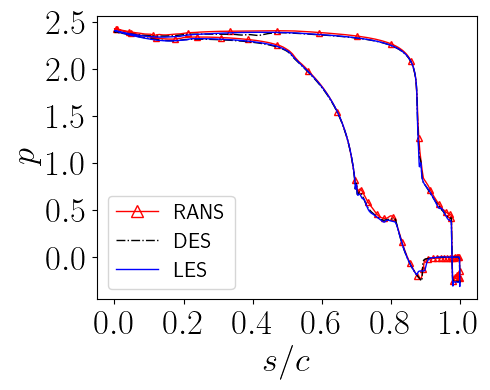

In [12]:
# %matplotlib widget

font = 25
markerscale=2
legends = ['RANS','DES','LES','LES R134a']

# Get reference values
# ====================
var = 'p'
x1s = [0,30,50]
x2s = [10,50,70]
y1s = [45,80,130]
y2s = [50,100,150]


uref = []
roref = []
pref = []
for ii,dir_data in enumerate(dirs_data):
#     plt.figure(figsize=(7,4))
#     plt.rcParams['text.usetex'] = True
#     for bl in range(n_bl):
#         bl+=1
#         plt.pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
#                        comp_data[f'{ii}'][f'block_{bl}']['y'],\
#                        comp_data[f'{ii}'][f'block_{bl}'][var],\
#                        vmin=7e4,vmax=8e5,cmap='RdBu_r')

#     plt.xlabel(r'$x/c$',fontsize=font)
#     plt.ylabel(r'$y/c$',fontsize=font)
#     plt.xticks(fontsize=font)
#     plt.yticks(fontsize=font)
#     plt.xlim(0.95,1.05)
#     plt.ylim(-0.25,-0.15)
    
#     # Spatial average

    x1,x2 = x1s[ii],x2s[ii]
    y1,y2 = y1s[ii],y2s[ii]
#     plt.pcolormesh(comp_data[f'{ii}'][f'block_6']['x'][x1:x2,y1:y2],\
#                    comp_data[f'{ii}'][f'block_6']['y'][x1:x2,y1:y2],\
#                    comp_data[f'{ii}'][f'block_6']['p'][x1:x2,y1:y2],cmap='binary')    
#     plt.colorbar()
#     plt.tight_layout()
#     # plt.savefig('Figures_LS59_Stefan/Mis_wall_mesh_convergence.pdf',format='pdf')
#     plt.show()
    
    # Compute reference quantities
    thet = 75*np.pi/180
    uref_ = comp_data[f'{ii}'][f'block_6']['u'][x1:x2,y1:y2]*np.cos(thet) -\
            comp_data[f'{ii}'][f'block_6']['v'][x1:x2,y1:y2]*np.sin(thet)
    uref.append(np.mean(uref_))
    roref.append(np.mean(comp_data[f'{ii}'][f'block_6']['rho'][x1:x2,y1:y2]))
    pref.append(np.mean(comp_data[f'{ii}'][f'block_6']['p'][x1:x2,y1:y2]))
        
    

    

# Denton definition of Cp
# =======================

plt.figure(figsize=(5,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
        
    plt.plot(comp_data[f'{ii}']['xw'],(comp_data[f'{ii}']['pw']-pref[ii])/0.5/roref[ii]/uref[ii]**2,\
            styles[ii],linewidth=1,markevery=10,markersize=4,markerfacecolor='none',\
             label=legends[ii])

# Exp data
# plt.plot(x,Mis_sanz,'sk',markerfacecolor='None')
plt.xlabel(r'$s/c$',fontsize=font)
plt.ylabel(r'$p$',fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.legend(prop={'size':font-10},markerscale=markerscale)
plt.tight_layout()
# plt.savefig('Figures_LS59_Stefan/Mis_wall_mesh_convergence.pdf',format='pdf')
plt.show()

# Loss coefficient ETMM

IndexError: list index out of range

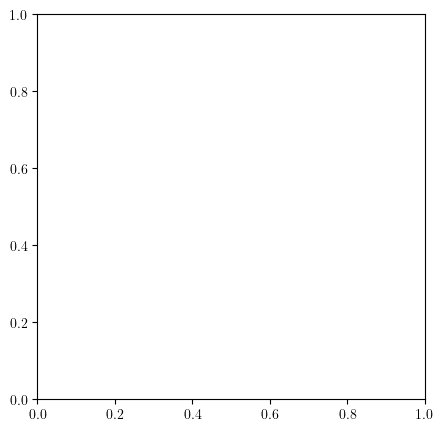

In [13]:
# Cpbs = [0.315,0.343,0.450,0.265]
Cpbs = [0.200,0.255,0.264]
t = 2.5e-2 # T.E thickness
ind = -30

bp_air,bp_nov = [],[]
mom_air,mom_nov = [],[]
blo_air,blo_nov = [],[]
for ii,dir_data in enumerate(dirs_data):
    
    delta_t = comp_data[f'{ii}']['delta_t']
    theta_t = comp_data[f'{ii}']['theta_t']
    zeta = Cpbs[ii]*t/pitch + 2*theta_t[ind]/pitch + (delta_t[ind]+t)**2/pitch**2
    comp_data[f'{ii}']['zeta'] = zeta

    if fluids[ii]=='air':
        bp_air.append(Cpbs[ii]*t/pitch/zeta)
        mom_air.append(2*theta_t[ind]/pitch/zeta)
        blo_air.append((delta_t[ind]+t)**2/pitch**2/zeta)
    else:
        bp_nov.append(Cpbs[ii]*t/pitch/zeta)
        mom_nov.append(2*theta_t[ind]/pitch/zeta)
        blo_nov.append((delta_t[ind]+t)**2/pitch**2/zeta)
    
font=20
markerscale=2
markersize=8
markevery=5
width=1.2
lw=1.3
styles = ['b','r','g','k']

fig,ax = plt.subplots(figsize=(5,5))
plt.rcParams['text.usetex'] = True

offset = 0
j = 0
for i in range(2):
    i+=1
    i+=offset
    plt.bar(i,blo_air[j],width=width,linewidth=2,fill=True,facecolor='r', edgecolor='black',hatch=("///"))
    plt.bar(i,mom_air[j],width=width,linewidth=2,fill=True,facecolor='r', edgecolor='black',hatch=("x"),bottom=blo_air[j])
    plt.bar(i,bp_air[j],width=width,linewidth=2,fill=True,facecolor='r', edgecolor='black',hatch=("\\"),bottom=mom_air[j]+blo_air[j])
    offset+=i+1
    j+=1

j = 0
for i in range(2):
    i+=1
    i+=offset
    plt.bar(i,blo_nov[j],width=width,linewidth=2,fill=True,facecolor='b',edgecolor='black',hatch=("///"))
    plt.bar(i,mom_nov[j],width=width,linewidth=2,fill=True,facecolor='b',edgecolor='black',hatch=("x"),bottom=blo_nov[j])
    plt.bar(i,bp_nov[j],width=width,linewidth=2,fill=True,facecolor='b',edgecolor='black',hatch=("\\"),bottom=mom_nov[j]+blo_nov[j])
    offset+=2
    j+=1

plt.xticks([1,4,8,11],[r'RANS',r'LES',r'RANS',r'LES'],fontsize=font)
plt.yticks(fontsize=font)
plt.ylabel(r'$\zeta/\zeta_{tot}$',fontsize=font)
plt.ylim(0,1.15)
plt.xlim(0,)

# Annotations
plt.plot([6,6],[0,1.15],'--k')
plt.annotate(r'Air',(2,1.05),fontsize=font)
plt.annotate(r'R134a',(8,1.05),fontsize=font)

# plt.xlim(-0.5,3.5)
# Legends
plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("///"),label=r'$\zeta_{\delta^*}$')
plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("x"),label=r'$\zeta_\theta$')
plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("\\"),label=r'$\zeta_{C_{p,b}}$')

plt.legend(prop={'size':font-2},markerscale=1,bbox_to_anchor=(1,-0.1),ncol=3)
plt.tight_layout()
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/cpb_zeta.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/cpb_zeta.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/zeta.pdf',format='pdf')
plt.show()

# Loss coeff ASME

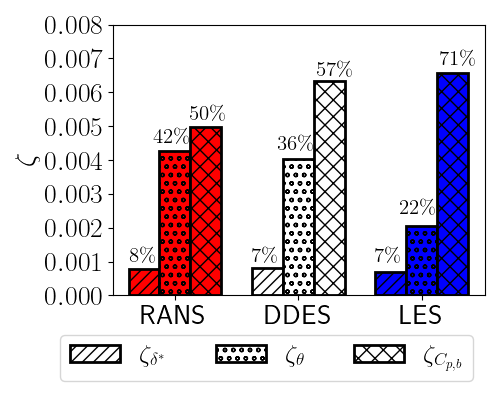

In [17]:
%matplotlib widget

Cpbs = [0.200,0.255,0.264]
t = 2.5e-2 # T.E thickness
ind = -30

bp = []
mom = []
blo = []
for ii,dir_data in enumerate(dirs_data):
    
    delta_t = comp_data[f'{ii}']['delta_t']
    theta_t = comp_data[f'{ii}']['theta_t']
    zeta = Cpbs[ii]*t/pitch + 2*theta_t[ind]/pitch + (delta_t[ind]+t)**2/pitch**2
    comp_data[f'{ii}']['zeta'] = zeta

    # Normalized
    # bp.append(Cpbs[ii]*t/pitch/zeta)
    # mom.append(2*theta_t[ind]/pitch/zeta)
    # blo.append((delta_t[ind]+t)**2/pitch**2/zeta)
    
    # Non-normalized
    bp.append(Cpbs[ii]*t/pitch)
    mom.append(2*theta_t[ind]/pitch)
    blo.append((delta_t[ind]+t)**2/pitch**2)
    
font=20
markerscale=2
markersize=8
markevery=5
width=1
lw=1.3

fig,ax = plt.subplots(figsize=(5,4))
plt.rcParams['text.usetex'] = True

# Blockage
offset = 0
j = 0
for i in range(len(dirs_data)):
    i+=1
    i+=offset
    if styles[j][-1]=='k':
        plt.bar(i,blo[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=("///"))
    else:
        plt.bar(i,blo[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=("///"))
    offset+=3
    j+=1
    
# Momentum
offset = 0
j = 0
for i in range(len(dirs_data)):
    i+=2
    i+=offset
    if styles[j][-1]=='k':
        plt.bar(i,mom[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=("oo"))
    else:
        plt.bar(i,mom[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=("oo"))
    offset+=3
    j+=1
    
# Back pressure
offset = 0
j = 0
for i in range(len(dirs_data)):
    i+=3
    i+=offset
    if styles[j][-1]=='k':
        plt.bar(i,bp[j],width=width,linewidth=2,fill=True,facecolor='w',edgecolor='black',hatch=("xx"))
    else:
        plt.bar(i,bp[j],width=width,linewidth=2,fill=True,facecolor=styles[j][-1],edgecolor='black',hatch=("xx"))
    offset+=3
    j+=1




plt.xticks([2,6,10],[r'RANS',r'DDES',r'LES'],fontsize=font)
plt.yticks(fontsize=font)
plt.ylabel(r'$\zeta$',fontsize=font)
plt.ylim(0,0.008)
plt.xlim(0,)

# Annotations
# -----------
# RANS
plt.annotate(r'$8\%$' ,(0.5,0.001),fontsize=font-5)
plt.annotate(r'$42\%$',(1.3,0.0045),fontsize=font-5)
plt.annotate(r'$50\%$',(2.5,0.0052),fontsize=font-5)
# DES
plt.annotate(r'$7\%$' ,(4.5,0.001),fontsize=font-5)
plt.annotate(r'$36\%$',(5.3,0.0043),fontsize=font-5)
plt.annotate(r'$57\%$',(6.6,0.0065),fontsize=font-5)
# LES
plt.annotate(r'$7\%$' ,(8.5,0.001),fontsize=font-5)
plt.annotate(r'$22\%$',(9.3,0.0024),fontsize=font-5)
plt.annotate(r'$71\%$',(10.6,0.0068),fontsize=font-5)


# plt.plot([6,6],[0,1.15],'--k')
# plt.annotate(r'Air',(2,1.05),fontsize=font)
# plt.annotate(r'R134a',(8,1.05),fontsize=font)

# plt.xlim(-0.5,3.5)
# Legends
plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("///"),label=r'$\zeta_{\delta^*}$')
plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("oo"),label=r'$\zeta_\theta$')
plt.bar(-5,0,width=width,linewidth=2,fill=False,edgecolor='black',hatch=("xx"),label=r'$\zeta_{C_{p,b}}$')

plt.legend(prop={'size':font-2},markerscale=1,bbox_to_anchor=(1,-0.1),ncol=3)
plt.tight_layout()
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/cpb_zeta.pdf',format='pdf')
# plt.savefig(f'/home/matar/Documents/Articles/FTaC/Figures/cpb_zeta.eps',format='eps')
# plt.savefig(f'Figures/ETMM_proceeding/zeta.pdf',format='pdf')
plt.savefig(f'Figures/ASME/Denton_loss.pdf',format='pdf')
plt.show()